In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib.patches as mpatches  # For patterns

import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib.patches as mpatches  # For patterns

from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import norm
import seaborn as sns
from scipy.stats import chi2_contingency

from scipy.signal import find_peaks

In [321]:
file_path = '/Users/jesanahammed/Desktop/dataset/faculty_data_raw_3_june.csv'
df = pd.read_csv(file_path, encoding='latin1')
df.columns = df.columns.str.replace(r'[^\x00-\x7F]+', '', regex=True)  # Remove non-ASCII characters
df.columns = df.columns.str.strip()  # Strip any leading/trailing spaces

In [322]:
response_id = df["Response ID"]

In [323]:
print(len(response_id))

142


In [324]:
df_filtered = df[df["Response Status"] == "Completed"]

In [325]:
response_id = df_filtered["Response ID"]
print(len(response_id))

98


In [326]:
test_response = df_filtered["External Reference"]
test_response.value_counts()

External Reference
test_response    3
Name: count, dtype: int64

In [327]:
df_new = df_filtered[df_filtered["External Reference"] != "test_response"]

In [328]:
test_response = df_new["External Reference"]
test_response.value_counts()

Series([], Name: count, dtype: int64)

In [329]:
response_id = df_new["Response ID"]
print(len(response_id))

95


In [330]:
response_id.isna().sum()

0

In [331]:
genai = df_new["Please rate how frequently you have used the following GenAI-based tools for your classes, research, and/or any other professional efforts"]

In [332]:
genai.value_counts().sum()

95

In [333]:
genai.value_counts()/95*100

Please rate how frequently you have used the following GenAI-based tools for your classes, research, and/or any other professional efforts
Once or Twice                                      35.789474
Never                                              29.473684
Regularly (Once or twice a week)                   18.947368
All the time (daily, or more often)                 9.473684
Have only used for fun or curiosity, never work     6.315789
Name: count, dtype: float64

In [17]:
genai.isna().sum()

0

In [18]:
ben_harm = df_new["Please rate your current feelings on whether generative AI will be beneficial or harmful to your field. (1) Extremely harmful to (10) Extremely beneficial Row 1"]

In [19]:
ben_harm.isna().sum()

0

In [20]:
ben_harm.value_counts()

Please rate your current feelings on whether generative AI will be beneficial or harmful to your field. (1) Extremely harmful to (10) Extremely beneficial Row 1
5.0     21
7.0     15
6.0     14
9.0     11
10.0     9
8.0      9
3.0      6
4.0      5
2.0      4
1.0      1
Name: count, dtype: int64

In [789]:
def kde_plot(data, min, max, title, xlabel, ylabel):
    plt.figure(figsize=(10, 6))
    
    # KDE Plot with Clipping
    sns.kdeplot(data, clip=(min, max))
    plt.xlim(min, max)
    
    # Generate KDE data for finding peaks
    kde_data = sns.kdeplot(data, clip=(min, max)).get_lines()[0].get_data()
    x = kde_data[0]  # X values
    y = kde_data[1]  # Y values (density values)
    
    # Find peaks
    peaks, _ = find_peaks(y)  # Locate peaks in KDE curve
    
    # Plot the peaks on the KDE plot
    plt.plot(x[peaks], y[peaks], "ro")  # Mark peaks with red dots
    for peak in peaks:
        plt.text(x[peak], y[peak] + 0.0001,  # Offset slightly above the peak, 0.0001 for p(doom) estimation
                 f'{x[peak]:.2f}', ha='center', va='bottom', color='red', fontsize=35, fontweight='bold')  # Bigger peak values
    
    # Adjust x and y-axis ticks
    plt.tick_params(axis='both', labelsize=25)  # Make x and y-axis ticks bigger

    # Set x-axis ticks to range from 1 to 10
    ticks = np.linspace(min, max, 10)  # Create 10 evenly spaced ticks # ticks for rating
    #ticks = np.linspace(min, max, 7)  # ticks for p(doom)
    plt.xticks(ticks, labels=[f'{int(tick)}' for tick in ticks], fontsize=20)  # Format as integers and increase font size
    
    
    # Remove x and y labels
    plt.xlabel('')
    plt.ylabel('')

    plt.savefig('/Users/jesanahammed/Desktop/existing_vs_new.png', dpi=300)
    
    # Show the plot
    address = '/Users/jesanahammed/Desktop/' + title
    plt.savefig(address, dpi=300)
    plt.show()
    
    # Print the peak values
    peak_values = x[peaks]
    print(f"Peak values are at: {peak_values}")

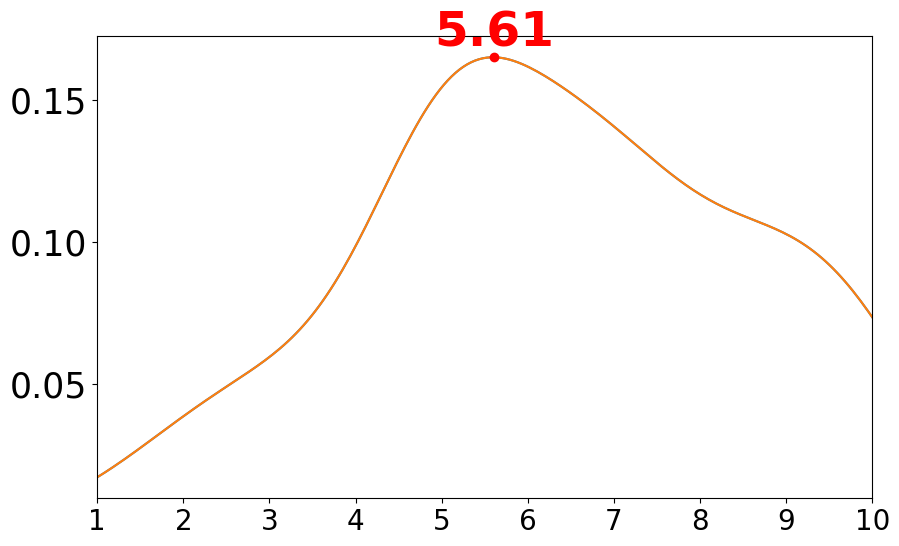

Peak values are at: [5.61306533]


In [792]:
kde_plot(ben_harm, 1, 10, 'A', 'X', 'Y')

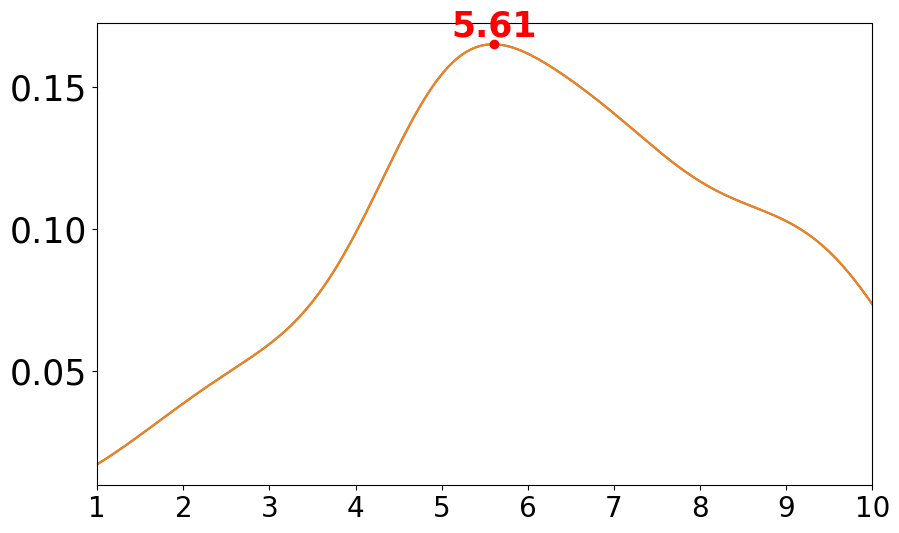

Peak values are at: [5.61306533]


In [22]:
kde_plot(ben_harm, 1, 10, 'A', 'X', 'Y')

In [23]:
str = "To what extent do you feel GenAI can provide pedagogical benefit to your Fall23 courses? (1) Extremely damaging to (10) Extremely beneficial Row 1"
str

'To what extent do you feel GenAI can provide pedagogical benefit to your Fall23 courses? (1)\xa0Extremely damaging to (10) Extremely beneficial Row 1'

In [24]:
import pandas as pd

# Assuming df is your DataFrame
for idx, col in enumerate(df_new.columns):
    print(f"{idx}: {col}")


0: Response ID
1: Response Status
2: IP Address
3: Timestamp (mm/dd/yyyy)
4: Duplicate
5: Time Taken to Complete (Seconds)
6: Seq. Number
7: External Reference
8: Custom Variable 1
9: Custom Variable 2
10: Custom Variable 3
11: Custom Variable 4
12: Custom Variable 5
13: Respondent Email
14: Email List
15: Country Code
16: Region
17: TITLE OF PROJECT: Mines Stakeholder Perspectives on the Uses of Generative AI in and out of the Classroom NAME OF PRINCIPAL INVESTIGATOR(S): C. Estelle Smith, PhDCONTACT NAME AND PHONE NUMBER FOR QUESTIONS/PROBLEMS: C. Estelle Smith, PhD, estellesmith@mines.edu, 612.226.7789SURVEY CLOSES at midnight on Wednesday, September 20, 2023. PURPOSE OF THE RESEARCH: At the end of the Spring23 semester, a survey was conducted of the full Mines student body on Generative Artificial Intelligence (GenAI). (Prominent examples of GenAI-based tools include: ChatGPT, Bard, Github Co-Pilot, Midjourney, DALL-E.) These data were used to inform the development of new Mines gui

In [25]:
ben_harm_course = df_new["To what extent do you feel GenAI can provide pedagogical benefit to your Fall23 courses? (1)Extremely damaging to (10) Extremely beneficial Row 1"]

In [26]:
ben_harm_course.value_counts()

To what extent do you feel GenAI can provide pedagogical benefit to your Fall23 courses? (1)Extremely damaging to (10) Extremely beneficial Row 1
5.0     31
6.0     20
7.0      8
1.0      7
3.0      7
2.0      7
10.0     5
8.0      5
9.0      3
4.0      1
Name: count, dtype: int64

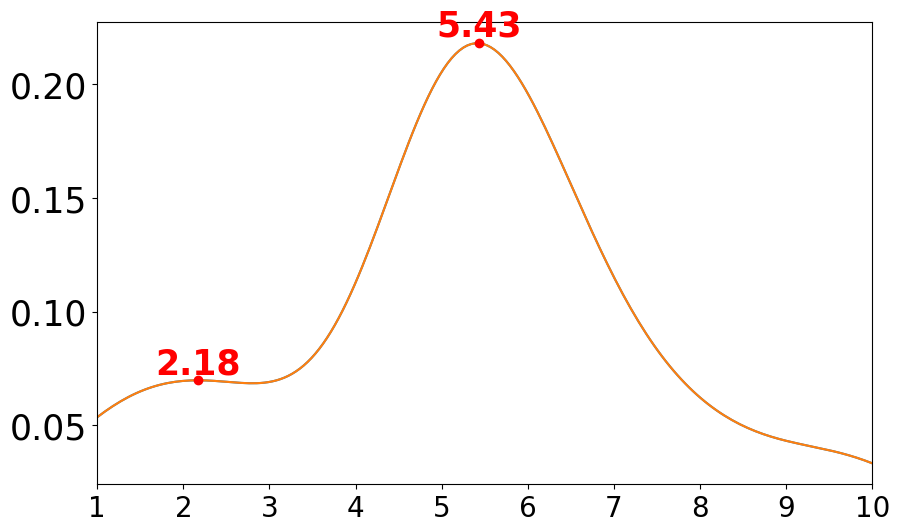

Peak values are at: [2.1758794 5.4321608]


In [27]:
kde_plot(ben_harm_course, 1, 10, 'A', 'X', 'Y')

In [28]:
print(ben_harm_course.mean())
print(ben_harm_course.median())

5.25531914893617
5.0


In [29]:

ben_harm_course.isna().sum()

1

In [30]:
ben_harm_clean = ben_harm_course.dropna()
ben_harm_clean.isna().sum()

0

In [31]:
from scipy.stats import wilcoxon

w_stat, p_val_w = wilcoxon([r - 5.5 for r in ben_harm_clean])  # Testing if responses differ from 5

print(f"Wilcoxon Test Statistic: {w_stat}, P-Value: {p_val_w:.10e}")

Wilcoxon Test Statistic: 1975.5, P-Value: 3.2240400931e-01


In [32]:
# How have engineering students adopted GenAI, and what motivational and demographic factors contribute to its usage — and how do faculty perspectives align or differ?


In [33]:
file_path = '/Users/jesanahammed/Desktop/dataset/GenAI.csv'
df_24 = pd.read_csv(file_path, encoding='latin1')
df_24.columns = df_24.columns.str.replace(r'[^\x00-\x7F]+', '', regex=True)  # Remove non-ASCII characters
df_24.columns = df_24.columns.str.strip()  # Strip any leading/trailing spaces

In [34]:
print(len(df_24['Response ID']))

862


In [35]:
file_path = '/Users/jesanahammed/Desktop/dataset/MOD - RAW - GenAI Survey Responses(Text).csv'
df_2023 = pd.read_csv(file_path, encoding='latin1')

In [36]:
print(len(df_2023['Response ID']))

879


In [37]:
dept = df_2023['What department or program are you in?']
deg = df_2023['What degree are you enrolled in?']
year = df_2023['How many years have you been at Mines?']
count = 0
for i in range(len(dept)):
    if not pd.isna(dept[i]) and not pd.isna(deg[i]) and not pd.isna(year[i]):
        count += 1
print(count)

601


In [38]:
df_2023_cleaned = df_2023.dropna(subset=['What department or program are you in?', 
                                         'What degree are you enrolled in?', 
                                         'How many years have you been at Mines?'])

# Reset the index and drop the old index column
df_2023_cleaned.reset_index(drop=True, inplace=True)

print(len(df_2023_cleaned['What department or program are you in?']))


601


In [39]:
# frequency of usages 

In [40]:
def two_proportion_z_test(n1, n2, x1, x2):
    # Perform the two-proportion z-test
    count = [x1, x2]
    nobs = [n1, n2]
    z_stat, p_value = proportions_ztest(count, nobs)
    
    print(f"Z-Statistic: {z_stat:.4f}")
    print(f"P-Value: {p_value:.4f}")
    # Calculate the P-value from the Z-statistic
    p_value_exact = 2 * norm.sf(abs(z_stat))
    print(f"Exact P-Value: {p_value_exact:.2e}")
        
    # Interpretation
    if p_value < 0.05:
        print("The change in proportions is statistically significant.")
    else:
        print("The change in proportions is not statistically significant.")


In [47]:
genai.value_counts()/95 * 100 # Faculty usages

Please rate how frequently you have used the following GenAI-based tools for your classes, research, and/or any other professional efforts
Once or Twice                                      35.789474
Never                                              29.473684
Regularly (Once or twice a week)                   18.947368
All the time (daily, or more often)                 9.473684
Have only used for fun or curiosity, never work     6.315789
Name: count, dtype: float64

In [42]:
freq_llm_2023 = df_2023_cleaned['Please rate how frequently you have used the following genAI-based tools for your classes, research, and/or any other professional efforts.  - Large Language Models (e.g. ChatGPT, Bard, etc.)']

In [48]:
freq_llm_2023.value_counts() / 601 * 100

Please rate how frequently you have used the following genAI-based tools for your classes, research, and/or any other professional efforts.  - Large Language Models (e.g. ChatGPT, Bard, etc.)
Never                                              30.782030
Once or twice                                      30.782030
Regularly (once or twice a week)                   22.462562
All the time (daily, or more often)                 9.317804
Have only used for fun or curiosity, never work     6.655574
Name: count, dtype: float64

In [44]:
freq_llm_2024 = df_24['LLM-powered chatbots (e.g. ChatGPT Gemini Claude Llama etc.)']


In [49]:
freq_llm_2024.value_counts() / 862 * 100

LLM-powered chatbots (e.g. ChatGPT Gemini Claude Llama etc.)
3    32.250580
2    30.510441
1    17.865429
4    12.761021
5     6.612529
Name: count, dtype: float64

In [78]:
# Never

In [80]:
two_proportion_z_test(95, 601, 28,185) # faculty vs 2023

Z-Statistic: -0.2571
P-Value: 0.7971
Exact P-Value: 7.97e-01
The change in proportions is not statistically significant.


In [81]:
two_proportion_z_test(95, 862, 28, 154)

Z-Statistic: 2.7362
P-Value: 0.0062
Exact P-Value: 6.21e-03
The change in proportions is statistically significant.


In [82]:
# Irregular (Once or Twice)

In [83]:
two_proportion_z_test(95, 601, 34, 185)

Z-Statistic: 0.9766
P-Value: 0.3287
Exact P-Value: 3.29e-01
The change in proportions is not statistically significant.


In [86]:
two_proportion_z_test(95, 862, 34, 263)

Z-Statistic: 1.0555
P-Value: 0.2912
Exact P-Value: 2.91e-01
The change in proportions is not statistically significant.


In [87]:
# Regular user

In [88]:
two_proportion_z_test(95, 601, 18, 135)

Z-Statistic: -0.7688
P-Value: 0.4420
Exact P-Value: 4.42e-01
The change in proportions is not statistically significant.


In [89]:
two_proportion_z_test(95, 862, 18, 278)

Z-Statistic: -2.6624
P-Value: 0.0078
Exact P-Value: 7.76e-03
The change in proportions is statistically significant.


In [90]:
# Super user

In [91]:
two_proportion_z_test(95, 601, 9, 56)

Z-Statistic: 0.0485
P-Value: 0.9613
Exact P-Value: 9.61e-01
The change in proportions is not statistically significant.


In [92]:
two_proportion_z_test(95, 862, 9, 110)

Z-Statistic: -0.9216
P-Value: 0.3568
Exact P-Value: 3.57e-01
The change in proportions is not statistically significant.


In [93]:
# Fun

In [94]:
two_proportion_z_test(95, 601, 6, 40)

Z-Statistic: -0.1239
P-Value: 0.9014
Exact P-Value: 9.01e-01
The change in proportions is not statistically significant.


In [95]:
two_proportion_z_test(95, 862, 6, 57)

Z-Statistic: -0.1107
P-Value: 0.9119
Exact P-Value: 9.12e-01
The change in proportions is not statistically significant.


In [96]:
# Other GeanAI tools

In [97]:
img_fac = df_new["Please rate how frequently you have used the following GenAI-based tools for your classes, research, and/or any other professional efforts.1"]

In [98]:
img_2023 = df_2023_cleaned['Please rate how frequently you have used the following genAI-based tools for your classes, research, and/or any other professional efforts.  - Image Generators (e.g. DALL-E, Midjourney)']

In [100]:
img_2024 = df_24['Image generators(e.g. DALL-E Midjourney etc.)']

In [101]:
img_fac.value_counts()

Please rate how frequently you have used the following GenAI-based tools for your classes, research, and/or any other professional efforts.1
Never                                              64
Once or Twice                                      20
Have only used for fun or curiosity, never work     6
Regularly (Once or twice a week)                    5
Name: count, dtype: int64

In [102]:
img_2023.value_counts()

Please rate how frequently you have used the following genAI-based tools for your classes, research, and/or any other professional efforts.  - Image Generators (e.g. DALL-E, Midjourney)
Never                                              429
Once or twice                                       89
Have only used for fun or curiosity, never work     66
Regularly (once or twice a week)                    15
All the time (daily, or more often)                  2
Name: count, dtype: int64

In [103]:
img_2024.value_counts()

Image generators(e.g. DALL-E Midjourney etc.)
1    501
2    199
5    134
3     25
4      3
Name: count, dtype: int64

In [104]:
two_proportion_z_test(95, 601, 64, 429)

Z-Statistic: -0.7996
P-Value: 0.4240
Exact P-Value: 4.24e-01
The change in proportions is not statistically significant.


In [105]:
two_proportion_z_test(95, 862, 64, 501)

Z-Statistic: 1.7396
P-Value: 0.0819
Exact P-Value: 8.19e-02
The change in proportions is not statistically significant.


In [106]:
two_proportion_z_test(95, 601, 20, 89)

Z-Statistic: 1.5561
P-Value: 0.1197
Exact P-Value: 1.20e-01
The change in proportions is not statistically significant.


In [108]:
two_proportion_z_test(95, 862, 20, 199)

Z-Statistic: -0.4477
P-Value: 0.6544
Exact P-Value: 6.54e-01
The change in proportions is not statistically significant.


In [109]:
two_proportion_z_test(95, 601, 6, 66)

Z-Statistic: -1.3877
P-Value: 0.1652
Exact P-Value: 1.65e-01
The change in proportions is not statistically significant.


In [111]:
two_proportion_z_test(95, 862, 6, 25)

Z-Statistic: 1.7846
P-Value: 0.0743
Exact P-Value: 7.43e-02
The change in proportions is not statistically significant.


In [112]:
# Conclusion: No significant changes is detected

In [113]:
# Coding Assistance (Facultuy)

In [114]:
coding_fac = df_new["Please rate how frequently you have used the following GenAI-based tools for your classes, research, and/or any other professional efforts.2"]

In [115]:
coding_fac.value_counts()

Please rate how frequently you have used the following GenAI-based tools for your classes, research, and/or any other professional efforts.2
Never                                              75
Once or Twice                                       9
Regularly (Once or twice a week)                    7
All the time (daily, or more often)                 3
Have only used for fun or curiosity, never work     1
Name: count, dtype: int64

In [116]:
# Use case + Motivation (Faculty)

In [97]:
um = df_new["If you have ever used any genAI-based tool(s) for your classes, research, and/or professional efforts, please tell us about how you have used them, why you used them, and how you feel about your use of these tool(s)."]

In [99]:
count = 0
for value in um:
    if not pd.isna(value):
        print(value)
        print("\n")
        count += 1


Generating images for research talks and discussing research ideas with ChatGPT


Information on administrative policies and procedures. Ok to use them as long as you are not presenting the information as your own.


I use ChatGPT daily to draft friendly emails, policies, proposals, goals and sometimes images. It's like having a team of assistants that understand my every request and never second guess themselves. Never do I use the first response, but after a few prompts I end up with a helluva first draft. At the very least, I end up with a good structure. ChatGPT allows me to spend my time making progress instead of creating documents. I'll never go back.


Never


I've used chatGPT to translate code between languages and edit (shorten) text, as well as to get instructions on using a new software tool. I have found it sometimes helpful, but also dangerously often wrong. I have also asked it questions like 'what are the biggest unsolved problems in field x' - to explore/understand th

In [595]:
count = 0
for i in range(len(um)):
    if not pd.isna(um.iloc[i]):
        print(response_id.iloc[i])
        print(role.iloc[i])
        print(um.iloc[i])
        print("\n")
        count += 1

114801644.0
Tenure track faculty  Associate professor
Generating images for research talks and discussing research ideas with ChatGPT


114801654.0
Administrative faculty
Information on administrative policies and procedures. Ok to use them as long as you are not presenting the information as your own.


114801670.0
Administrative faculty
I use ChatGPT daily to draft friendly emails, policies, proposals, goals and sometimes images. It's like having a team of assistants that understand my every request and never second guess themselves. Never do I use the first response, but after a few prompts I end up with a helluva first draft. At the very least, I end up with a good structure. ChatGPT allows me to spend my time making progress instead of creating documents. I'll never go back.


114801704.0
Teaching faculty  Full professor
Never


114801781.0
Tenure track faculty  Assistant professor
I've used chatGPT to translate code between languages and edit (shorten) text, as well as to get 

In [125]:
print(count)

69


In [126]:
import sys
sys.path.append('../scripts')  # Adjust path as needed
from module import (
    count_usage_cases,
    create_degree_lists,
    count_cluster_wise,
    pre_vec,
    nordept,
    deptwisecount,
    normalized_dept_cluster,
    create_vector,
    create_vector2,
    clear_vec,
    culster_wise_val,
    create_con_table,
    chi_square_test,
    residuals_cal,
    create_group,
    normality_test,
    agostino_pearson_test,
    kruskal_wallis_test
)
from plots import ( grouped_bar_graph_horizontal_color, stacked_bar_graph, grouped_bar_graph_horizontal_color_white, boxplot,
    kde_plot,
    heatmap_plot
)


In [127]:
# designation vs frequency usages

In [334]:
role = df_new["What is your current role at Mines?"]
role.unique()

for value in role:
    if value == "Tenure track faculty  Full professor":
        print("Y")

Y
Y
Y
Y
Y
Y
Y
Y
Y
Y
Y
Y
Y
Y
Y
Y


In [335]:
role.value_counts()

What is your current role at Mines?
Administrative faculty                        16
Tenure track faculty  Full professor         16
Teaching faculty  Full professor             13
Adjunct faculty                               10
Tenure track faculty  Associate professor     9
Tenure track faculty  Assistant professor     8
Teaching faculty  Associate professor         8
Teaching faculty  Assistant professor         6
Postdoctoral staff or research faculty         4
Other (Please specify)                         2
Professor of practice                          2
Name: count, dtype: int64

In [130]:
contigency_table = create_con_table(role, genai)

In [131]:
contigency_table

"Please rate how frequently you have used the following GenAI-based tools for your classes, research, and/or any other professional efforts","All the time (daily, or more often)","Have only used for fun or curiosity, never work",Never,Once or Twice,Regularly (Once or twice a week)
What is your current role at Mines?,,,,,
Adjunct faculty,1,0,4,5,0
Administrative faculty,1,0,6,5,4
Other (Please specify),0,0,0,2,0
Postdoctoral staff or research faculty,1,1,1,1,0
Professor of practice,0,0,1,0,1
Teaching faculty  Assistant professor,0,1,2,2,1
Teaching faculty  Associate professor,2,0,0,3,3
Teaching faculty  Full professor,0,2,3,7,1
Tenure track faculty  Assistant professor,3,1,1,1,2


In [132]:
# Chi-square is unreliable as cells don't have value >= 5

In [134]:
# Regression: Frequency usages as dependent variable and Role as IV

In [336]:
data = pd.DataFrame({
    'Role': role,
    'Usage': genai
})

In [337]:
data['Role']

8      Tenure track faculty  Associate professor
9                          Administrative faculty
10                         Administrative faculty
11              Teaching faculty  Full professor
13          Tenure track faculty  Full professor
                          ...                    
137         Tenure track faculty  Full professor
138        Teaching faculty  Associate professor
139         Tenure track faculty  Full professor
140         Tenure track faculty  Full professor
141    Tenure track faculty  Assistant professor
Name: Role, Length: 95, dtype: object

In [160]:
from pandas.api.types import CategoricalDtype

# Define usage order
usage_order = CategoricalDtype(categories=['Never', 'Have only used for fun or curiosity, never work', 'Once or Twice', 'Regularly (Once or twice a week)', 'All the time (daily, or more often)'], ordered=True)

data['Usage'] = data['Usage'].astype(usage_order)

In [161]:
data['Usage']

8         Regularly (Once or twice a week)
9                            Once or Twice
10     All the time (daily, or more often)
11                                   Never
13                                   Never
                      ...                 
137                          Once or Twice
138    All the time (daily, or more often)
139                                  Never
140       Regularly (Once or twice a week)
141       Regularly (Once or twice a week)
Name: Usage, Length: 95, dtype: category
Categories (5, object): ['Never' < 'Have only used for fun or curiosity, never work' < 'Once or Twice' < 'Regularly (Once or twice a week)' < 'All the time (daily, or more often)']

In [162]:
X = pd.get_dummies(data['Role'], drop_first=True)  # drop_first avoids multicollinearity


In [163]:
X

,Administrative faculty,Other (Please specify),Postdoctoral staff or research faculty,Professor of practice,Teaching faculty  Assistant professor,Teaching faculty  Associate professor,Teaching faculty  Full professor,Tenure track faculty  Assistant professor,Tenure track faculty  Associate professor,Tenure track faculty  Full professor
8,False,False,False,False,False,False,False,False,True,False
9,True,False,False,False,False,False,False,False,False,False
10,True,False,False,False,False,False,False,False,False,False
11,False,False,False,False,False,False,True,False,False,False
13,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...
137,False,False,False,False,False,False,False,False,False,True
138,False,False,False,False,False,True,False,False,False,False
139,False,False,False,False,False,False,False,False,False,True
140,False,False,False,False,False,False,False,False,False,True


In [164]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

# Fit the model
model = OrderedModel(data['Usage'], X, distr='logit')
res = model.fit(method='bfgs')

# Summary of the model
print(res.summary())

Optimization terminated successfully.
         Current function value: 1.364920
         Iterations: 68
         Function evaluations: 70
         Gradient evaluations: 70
                             OrderedModel Results                             
Dep. Variable:                  Usage   Log-Likelihood:                -129.67
Model:                   OrderedModel   AIC:                             287.3
Method:            Maximum Likelihood   BIC:                             323.1
Date:                Wed, 11 Jun 2025                                         
Time:                        14:19:37                                         
No. Observations:                  95                                         
Df Residuals:                      81                                         
Df Model:                          10                                         
                                                                           coef    std err          z      P>|z|     

In [166]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

# After fitting your model:
llf = res.llf  # log-likelihood of full model
llnull = res.llnull  # log-likelihood of null model

pseudo_r2 = 1 - (llf / llnull)
print(f"McFadden's Pseudo R²: {pseudo_r2:.3f}")

McFadden's Pseudo R²: 0.053


In [170]:
# Industry exp

In [171]:
exp = df_new["How many years of full-time industry experience (i.e. public or private sector work outside of academia but within your current discipline) did you obtain in your field prior to beginning your role at Mines? (Please do not include internships or part-time roles.)"]

In [174]:
exp.value_counts()
print(exp)

8                 NaN
9         10-20 years
10        10-20 years
11          1-5 years
13         > 20 years
            ...      
137               NaN
138        > 20 years
139        5-10 years
140               NaN
141    1 year or less
Name: How many years of full-time industry experience (i.e. public or private sector work outside of academia but within your current discipline) did you obtain in your field prior to beginning your role at Mines? (Please do not include internships or part-time roles.), Length: 95, dtype: object


In [ ]:
data

In [173]:
from scipy.stats import spearmanr

correlation, p_value = spearmanr(exp, genai)
print(f"Spearman correlation: {correlation:.3f}, p-value: {p_value:.3f}")


Spearman correlation: nan, p-value: nan


In [175]:
experience_map = {
    'None': 0,
    '1 year or less': 1,
    '1-5 years': 2,
    '5-10 years': 3,
    '10-20 years': 4,
    '> 20 years': 5
}


In [176]:
genai_map = {
    'Never': 0,
    'Have only used for fun or curiosity, never work': 1,
    'Once or Twice': 2,
    'Regularly (Once or twice a week)': 3,
    'All the time (daily, or more often)': 4
}


In [177]:
df_new['exp_code'] = df_new[exp.name].map(experience_map)
df_new['genai_code'] = df_new[genai.name].map(genai_map)


/var/folders/v7/gphzyn511m1_qjvs14t04n000000gn/T/ipykernel_67453/3579508699.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['exp_code'] = df_new[exp.name].map(experience_map)
/var/folders/v7/gphzyn511m1_qjvs14t04n000000gn/T/ipykernel_67453/3579508699.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['genai_code'] = df_new[genai.name].map(genai_map)


In [178]:
subset = df_new[['exp_code', 'genai_code']].dropna()


In [179]:
from scipy.stats import spearmanr

corr, pval = spearmanr(subset['exp_code'], subset['genai_code'])
print(f"Spearman correlation: {corr:.3f}, p-value: {pval:.4f}")


Spearman correlation: -0.060, p-value: 0.6480


In [373]:
chal_opp = df_new["What do you see as the greatest challenges and opportunities for Mines faculty and staff in thoughtfully responding to the new availability of Generative AI models for our students and colleagues? How might GenAI impact learning outcomes and processes?"]

In [596]:

for i in range(len(chal_opp)):
    if not pd.isna(chal_opp.iloc[i]):
        print(response_id.iloc[i])
        print(role.iloc[i])
        print(chal_opp.iloc[i])
        print("\n\n")

114801644.0
Tenure track faculty  Associate professor
Altering teaching and evaluation strategies to accomodate access



114801654.0
Administrative faculty
I think having no policies or procedures around using GenAI at Mines would make it challenging and be harmful. I think it can be useful as long as individuals are using it appropriately.



114801670.0
Administrative faculty
The biggest challenge is restructuring classes around it. I remember when we were taught how to 'talk' to Google, and I assume the process will be similar.



114801704.0
Teaching faculty  Full professor
Academic dishonestly, particularly in lab settings. Not sure how to deal with so not sure how will impact.



114801762.0
Tenure track faculty  Full professor
Challenge: Coursework might become meaningless. Opportunity: Rapid access t



114801781.0
Tenure track faculty  Assistant professor
I think there are responsible ways to use these tools, but I worry about students' ability to discern them. I have see

In [183]:
count = 0
for val in chal_opp:
    if not pd.isna(val):
        print(val)
        print("\n")
        count += 1

Altering teaching and evaluation strategies to accomodate access


I think having no policies or procedures around using GenAI at Mines would make it challenging and be harmful. I think it can be useful as long as individuals are using it appropriately.


The biggest challenge is restructuring classes around it. I remember when we were taught how to 'talk' to Google, and I assume the process will be similar.


Academic dishonestly, particularly in lab settings. Not sure how to deal with so not sure how will impact.


Challenge: Coursework might become meaningless. Opportunity: Rapid access t


I think there are responsible ways to use these tools, but I worry about students' ability to discern them. I have seen students use GenAI to help with coding, but in cases I've observed, GenAI (1) doesn't solve the code problems appropriately and (2) risks delaying finding a solution when the students try to use/modify GenAI code instead learning the underlying processes. I'm also concerned abou

In [184]:
print(count)

90


In [185]:
pre = df_new["How prepared do you feel to integrate pedagogical uses of GenAI in your Fall23 courses?(1) Extremely unprepared to (10) Extremely prepared Row 1"]

In [186]:
pre.value_counts()

How prepared do you feel to integrate pedagogical uses of GenAI in your Fall23 courses?(1) Extremely unprepared to (10) Extremely prepared Row 1
2.0     18
1.0     17
5.0     15
3.0     15
4.0      9
7.0      6
8.0      5
6.0      5
9.0      3
10.0     1
Name: count, dtype: int64

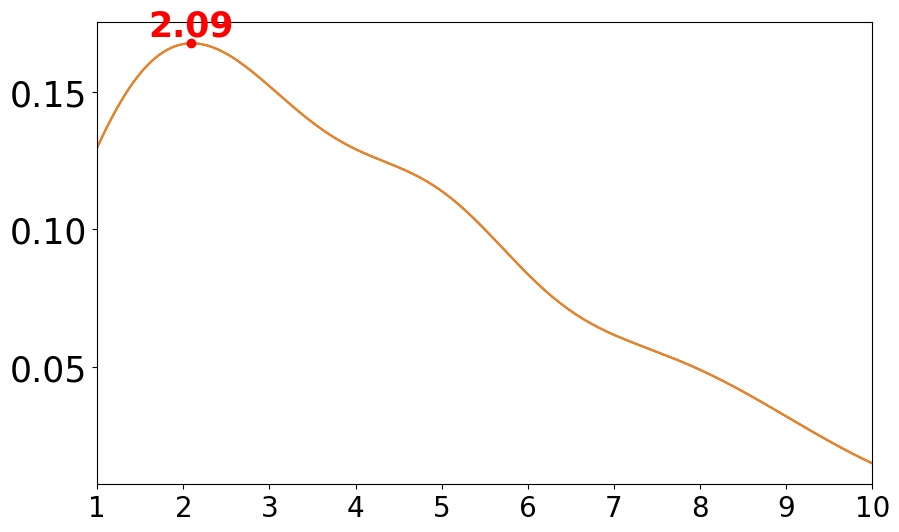

Peak values are at: [2.08542714]


In [204]:
kde_plot(pre, 1, 10, 'A', 'X', 'Y')

In [196]:
pre_dic = pre.value_counts().sort_values(ascending=False)


In [197]:
pre_dic

How prepared do you feel to integrate pedagogical uses of GenAI in your Fall23 courses?(1) Extremely unprepared to (10) Extremely prepared Row 1
2.0     18
1.0     17
5.0     15
3.0     15
4.0      9
7.0      6
8.0      5
6.0      5
9.0      3
10.0     1
Name: count, dtype: int64

In [395]:
def draw_barplot(data, xlabel, ylabel):
    plt.figure(figsize=(8, 6))
    ax = sns.barplot(x=data.index, y=data.values, palette="Blues_d")
    
    # Annotate bars with values
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.0f}',  
                    (p.get_x() + p.get_width() / 2, p.get_height()),  # Position
                    ha='center', va='bottom', fontsize=12, color='black', fontweight='bold')
   
    # Rotate X-axis labels
    plt.xticks(rotation=45, ha='right') 

    # Adding titles and labels
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.savefig('/Users/jesanahammed/Desktop/faculty_preparedness.png', dpi=300)
    
    # Show the plot
    plt.tight_layout()
    plt.show()

/var/folders/v7/gphzyn511m1_qjvs14t04n000000gn/T/ipykernel_67453/1680264997.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=data.index, y=data.values, palette="Blues_d")


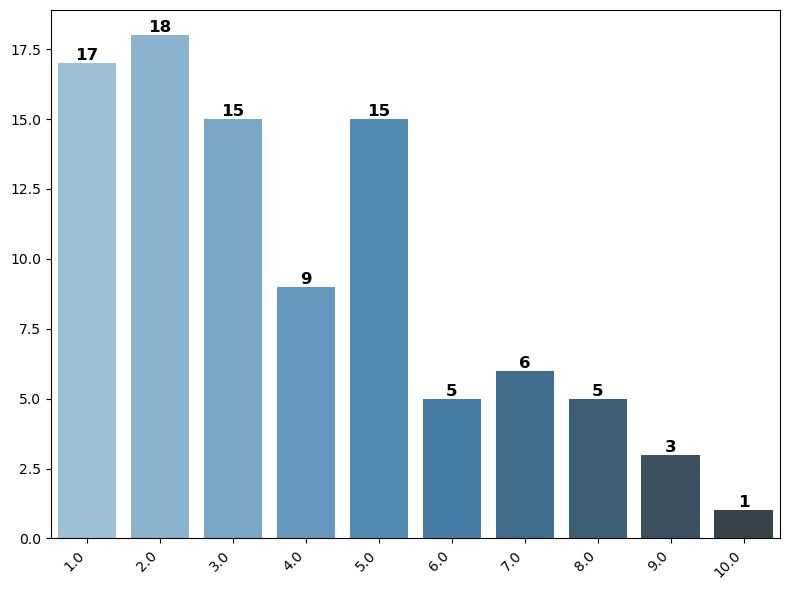

In [203]:
draw_barplot(pre_dic, "", "")

In [200]:
print(pre.mean())

3.8085106382978724


In [201]:
print(pre.median())

3.0


In [206]:
from scipy.stats import wilcoxon

w_stat, p_val_w = wilcoxon([r - 5.5 for r in pre])  # Testing if responses differ from 5

print(f"Wilcoxon Test Statistic: {w_stat}, P-Value: {p_val_w:.10e}")

Wilcoxon Test Statistic: nan, P-Value: nan


In [207]:
pre

8       2.0
9       1.0
10     10.0
11      1.0
13      1.0
       ... 
137     NaN
138     4.0
139     3.0
140     6.0
141     6.0
Name: How prepared do you feel to integrate pedagogical uses of GenAI in your Fall23 courses?(1) Extremely unprepared to (10) Extremely prepared Row 1, Length: 95, dtype: float64

In [209]:
ben_sci_2024 = df_24['Your scientific field or major']

In [210]:
ben_sci_2024_cleaned = ben_sci_2024.dropna()

In [211]:
ben_sci_2023 = df_2023_cleaned['Please rate your current feelings on whether generative AI will be beneficial or harmful for your field.']

In [212]:
mapping = {
    '7': 7,
    '9': 9,
    '6': 6,
    '8': 8,
    '5': 5,
    '10 (Extremely beneficial)': 10,
    '4': 4,
    '3': 3,
    '1 (Extremely harmful)': 1,
    '2': 2
}

# Convert the values to numeric using the mapping
ben_sci_2023_numeric = ben_sci_2023.replace(mapping).astype(int)

# Check the result
print(ben_sci_2023_numeric.unique())

[ 7  9  6  8  5 10  4  3  1  2]


In [222]:
ben_sci_faculty = df_new["Please rate your current feelings on whether generative AI will be beneficial or harmful to your field. (1) Extremely harmful to (10) Extremely beneficial Row 1"]

In [223]:
ben_sci_faculty.isna().sum()

0

In [224]:
ben_sci_faculty_cleaned = ben_sci_faculty.dropna()
ben_sci_faculty_cleaned.isna().sum()

0

In [225]:
print(f'Median 2023: {ben_sci_2023_numeric.median()}')
print(f'Median 2024: {ben_sci_2024_cleaned.median()}')
print(f'Median Faculty: {ben_sci_faculty_cleaned.median()}')


Median 2023: 7.0
Median 2024: 6.0
Median Faculty: 6.0


In [226]:
from scipy.stats import kruskal
kruskal(ben_sci_2023_numeric, ben_sci_2024_cleaned, ben_sci_faculty_cleaned)

KruskalResult(statistic=12.319133278302852, pvalue=0.0021131688379739076)

In [227]:
import scikit_posthocs as sp
sp.posthoc_dunn([ben_sci_2023_numeric, ben_sci_2024_cleaned, ben_sci_faculty_cleaned], p_adjust='bonferroni')


,1,2,3
1,1.000000,0.001358,1.0
2,0.001358,1.000000,1.0
3,1.000000,1.000000,1.0


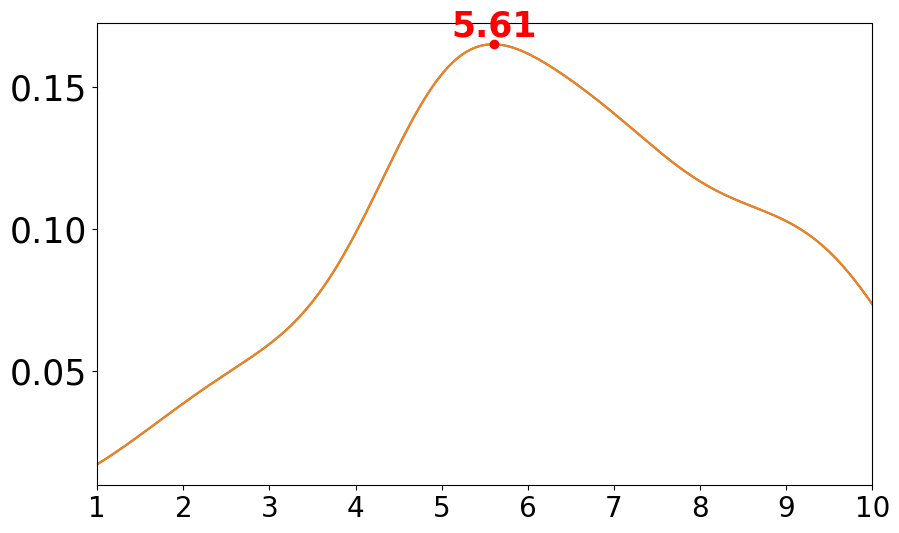

Peak values are at: [5.61306533]


In [228]:
kde_plot(ben_sci_faculty_cleaned, 1, 10, 'A', 'X', 'Y')

/var/folders/v7/gphzyn511m1_qjvs14t04n000000gn/T/ipykernel_67453/1680264997.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=data.index, y=data.values, palette="Blues_d")


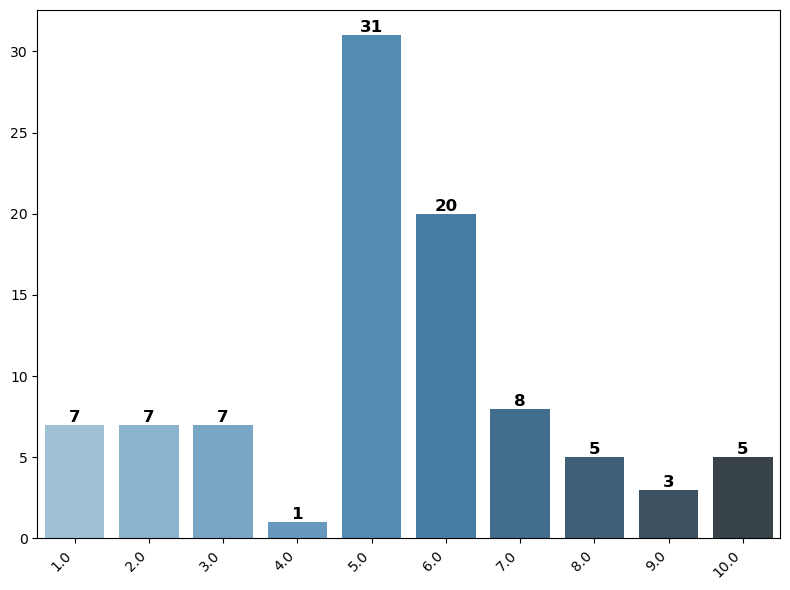

In [397]:
ben_harm = ben_harm_clean.value_counts().sort_values(ascending=False)
draw_barplot(ben_harm, "", "")

In [229]:
genai.value_counts() # Faculty usages

Please rate how frequently you have used the following GenAI-based tools for your classes, research, and/or any other professional efforts
Once or Twice                                      34
Never                                              28
Regularly (Once or twice a week)                   18
All the time (daily, or more often)                 9
Have only used for fun or curiosity, never work     6
Name: count, dtype: int64

In [604]:
ams = df_new["What do you consider to be your primary department?"]

In [605]:
ams.value_counts()

What do you consider to be your primary department?
0                                     89
Applied Mathematics and Statistics     6
Name: count, dtype: int64

In [607]:
cbe = df_new["Unnamed: 69"]
cbe.value_counts()

Unnamed: 69
0                                      92
Chemical and Biological Engineering     3
Name: count, dtype: int64

In [609]:
che = df_new["Unnamed: 70"]
che.value_counts()

Unnamed: 70
0            93
Chemistry     2
Name: count, dtype: int64

In [610]:
ce = df_new["Unnamed: 71"]
ce.value_counts()

Unnamed: 71
0                                      91
Civil and Environmental Engineering     4
Name: count, dtype: int64

In [611]:
cs = df_new["Unnamed: 72"]
cs.value_counts()

Unnamed: 72
0                   86
Computer Science     9
Name: count, dtype: int64

In [612]:
eb = df_new["Unnamed: 73"]
eb.value_counts()

Unnamed: 73
0                         92
Economics and Business     3
Name: count, dtype: int64

In [613]:
ee = df_new["Unnamed: 74"]
ee.value_counts()


Unnamed: 74
0    95
Name: count, dtype: int64

In [614]:
eds = df_new["Unnamed: 75"]
eds.value_counts()

Unnamed: 75
0                                 86
Engineering Design and Society     9
Name: count, dtype: int64

In [615]:
gge = df_new["Unnamed: 76"]
gge.value_counts()

Unnamed: 76
0                                     92
Geology and Geological Engineering     3
Name: count, dtype: int64

In [616]:
geop = df_new["Unnamed: 77"]
geop.value_counts()

Unnamed: 77
0             92
Geophysics     3
Name: count, dtype: int64

In [617]:
has = df_new["Unnamed: 78"]
has.value_counts()

Unnamed: 78
0                                        88
Humanities, Arts, and Social Sciences     7
Name: count, dtype: int64

In [618]:
me = df_new["Unnamed: 79"]
me.value_counts()

Unnamed: 79
0                         87
Mechanical Engineering     8
Name: count, dtype: int64

In [619]:
mme = df_new["Unnamed: 80"]
mme.value_counts()

Unnamed: 80
0                                          92
Metallurgical and Materials Engineering     3
Name: count, dtype: int64

In [620]:
mee = df_new["Unnamed: 81"]
mee.value_counts()


Unnamed: 81
0    95
Name: count, dtype: int64

In [621]:
mme.isna().sum()

0

In [622]:
pe = df_new["Unnamed: 82"]
pe.value_counts()

Unnamed: 82
0                        94
Petroleum Engineering     1
Name: count, dtype: int64

In [624]:
def num_of_res(att):
    count = 0
    for val in att:
        if not pd.isna(val) and val != '0' and val != 0:
            count += 1
            #print(val)
    return count

In [625]:
n = num_of_res(mee)
print(n)

0


In [626]:
phy = df_new["Unnamed: 83"]
phy.value_counts()

Unnamed: 83
0          89
Physics     6
Name: count, dtype: int64

In [627]:
au = df_new["Unnamed: 84"]
au.value_counts()

Unnamed: 84
0    95
Name: count, dtype: int64

In [628]:
af = df_new["Unnamed: 85"]
af.value_counts()

Unnamed: 85
0                               82
N/A - Administrative Faculty    13
Name: count, dtype: int64

In [629]:
other = df_new["Unnamed: 86"]
other.value_counts()

Unnamed: 86
0                                                             85
Library                                                        2
IT: Cyberinfrastructure & Advanced Research Computing team     1
Payne Institute                                                1
Research and Technology Transfer                               1
University Honors and Scholars Programs                        1
Nuclear Science and Engineering                                1
Other                                                          1
Mining Engineering--thanks for leaving us out                  1
RTT                                                            1
Name: count, dtype: int64

In [632]:
dept_df = pd.DataFrame({
    'ams': ams,
    'cbe': cbe,
    'che': che,
    'ce': ce,
    'cs': cs,
    'eb': eb,
    'ee': ee,
    'eds': eds,
    'gge': gge,
    'geop': geop,
    'has': has,
    'me': me,
    'mme': mme,
    'mee': mee,
    'pe': pe,
    'phy': phy,
    'au': au,
    'af': af,
    'other': other
})

In [639]:
print(dept_df.columns)

Index(['ams', 'cbe', 'che', 'ce', 'cs', 'eb', 'ee', 'eds', 'gge', 'geop',
       'has', 'me', 'mme', 'mee', 'pe', 'phy', 'au', 'af', 'other'],
      dtype='object')


In [648]:
num_all_zero_rows = (dept_df == '0').all(axis=1).sum()
print(num_all_zero_rows)

5


In [644]:
total = 0
for col in dept_df.columns:
    count = 0
    print(col)
    for val in dept_df[col]:
        if val != '0':
            print(val)
            total += 1
            count += 1
    print(count)

ams
Applied Mathematics and Statistics
Applied Mathematics and Statistics
Applied Mathematics and Statistics
Applied Mathematics and Statistics
Applied Mathematics and Statistics
Applied Mathematics and Statistics
6
cbe
Chemical and Biological Engineering
Chemical and Biological Engineering
Chemical and Biological Engineering
3
che
Chemistry
Chemistry
2
ce
Civil and Environmental Engineering
Civil and Environmental Engineering
Civil and Environmental Engineering
Civil and Environmental Engineering
4
cs
Computer Science
Computer Science
Computer Science
Computer Science
Computer Science
Computer Science
Computer Science
Computer Science
Computer Science
9
eb
Economics and Business
Economics and Business
Economics and Business
3
ee
0
eds
Engineering Design and Society
Engineering Design and Society
Engineering Design and Society
Engineering Design and Society
Engineering Design and Society
Engineering Design and Society
Engineering Design and Society
Engineering Design and Society
Engine

In [646]:
mech_civil = 4 + 8
cs_ee_ams = 6 + 9 + 0
met_geo_pet = 3 + 3 + 3 + 1 + 1
phy_chem = 3 + 2 + 6 + 1
soc = 3 + 9 + 7




print(mech_civil)
print(cs_ee_ams)
print(met_geo_pet)
print(phy_chem)
print(soc)

12
15
11
12
19


In [642]:
print(total)

90


In [277]:
n = num_of_res(phy)
print(n)

6


In [353]:
mech_civil = [0] * 5
cs_ee_ams = [0] * 5
met_geo_pet = [0] * 5
phys_chem = [0] * 5
society = [0]*5


In [740]:
def dept_count(att1, att2):
    tem = [0] * 5
    for i in range(len(att1)):
        if not pd.isna(att1.iloc[i]) and att1.iloc[i] != '0' and att1.iloc[i] != 0:
            if att2.iloc[i] == "Never":
                tem[0] += 1
            elif att2.iloc[i] == "Once or Twice":
                tem[1] += 1
            elif att2.iloc[i] == "Regularly (Once or twice a week)":
                tem[2] += 1
            elif att2.iloc[i] == "All the time (daily, or more often)":
                tem[3] += 1
            elif att2.iloc[i] == "Have only used for fun or curiosity, never work":
                tem[4] += 1
    return tem
            
        

In [355]:
tem = dept_count(ams, genai)
print(tem)
cs_ee_ams = [a + b for a, b in zip(cs_ee_ams, tem)]
print(cs_ee_ams)

[2, 2, 0, 2, 0]
[2, 2, 0, 2, 0]


In [356]:
tem = dept_count(cbe, genai)
print(tem)
phys_chem = [a + b for a, b in zip(phys_chem, tem)]
print(phys_chem)

[0, 1, 1, 0, 1]
[0, 1, 1, 0, 1]


In [357]:
tem = dept_count(che, genai)
print(tem)
phys_chem = [a + b for a, b in zip(phys_chem, tem)]
print(phys_chem)

[1, 0, 1, 0, 0]
[1, 1, 2, 0, 1]


In [358]:
tem = dept_count(ce, genai)
print(tem)
mech_civil = [a + b for a, b in zip(mech_civil, tem)]
print(mech_civil)

[2, 2, 0, 0, 0]
[2, 2, 0, 0, 0]


In [359]:
tem = dept_count(cs, genai)
print(tem)
cs_ee_ams = [a + b for a, b in zip(cs_ee_ams, tem)]
print(cs_ee_ams)

[2, 1, 4, 2, 0]
[4, 3, 4, 4, 0]


In [360]:
tem = dept_count(eb, genai)
print(tem)
society = [a + b for a, b in zip(society, tem)]
print(society)

[3, 0, 0, 0, 0]
[3, 0, 0, 0, 0]


In [361]:
tem = dept_count(ee, genai)
print(tem)
cs_ee_ams = [a + b for a, b in zip(cs_ee_ams, tem)]
print(cs_ee_ams)

[0, 0, 0, 0, 0]
[4, 3, 4, 4, 0]


In [362]:
tem = dept_count(gge, genai)
print(tem)
met_geo_pet = [a + b for a, b in zip(met_geo_pet, tem)]
print(met_geo_pet)

[0, 2, 0, 1, 0]
[0, 2, 0, 1, 0]


In [363]:
tem = dept_count(geop, genai)
print(tem)
met_geo_pet = [a + b for a, b in zip(met_geo_pet, tem)]
print(met_geo_pet)

[0, 1, 1, 1, 0]
[0, 3, 1, 2, 0]


In [364]:
tem = dept_count(has, genai)
print(tem)
society = [a + b for a, b in zip(society, tem)]
print(society)

[1, 4, 1, 0, 1]
[4, 4, 1, 0, 1]


In [365]:
tem = dept_count(me, genai)
print(tem)
mech_civil = [a + b for a, b in zip(mech_civil, tem)]
print(mech_civil)

[2, 4, 1, 0, 1]
[4, 6, 1, 0, 1]


In [366]:
tem = dept_count(mme, genai)
print(tem)
met_geo_pet = [a + b for a, b in zip(met_geo_pet, tem)]
print(met_geo_pet)

[1, 1, 1, 0, 0]
[1, 4, 2, 2, 0]


In [367]:
tem = dept_count(mee, genai)
print(tem)
met_geo_pet = [a + b for a, b in zip(met_geo_pet, tem)]
print(met_geo_pet)

[0, 0, 0, 0, 0]
[1, 4, 2, 2, 0]


In [368]:
tem = dept_count(pe, genai)
print(tem)
met_geo_pet = [a + b for a, b in zip(met_geo_pet, tem)]
print(met_geo_pet)

[0, 0, 1, 0, 0]
[1, 4, 3, 2, 0]


In [369]:
tem = dept_count(phy, genai)
print(tem)
phys_chem = [a + b for a, b in zip(phys_chem, tem)]
print(phys_chem)

[1, 2, 1, 1, 1]
[2, 3, 3, 1, 2]


In [738]:
admf = [0]*5

In [741]:
tem = dept_count(af, genai)
print(tem)
admf = [a + b for a, b in zip(admf, tem)]
print(admf)

[6, 3, 4, 0, 0]
[6, 3, 4, 0, 0]


In [372]:
print(mech_civil)
print(cs_ee_ams)
print(met_geo_pet)
print(phys_chem)
print(society)

[4, 6, 1, 0, 1]
[4, 3, 4, 4, 0]
[1, 4, 3, 2, 0]
[2, 3, 3, 1, 2]
[4, 4, 1, 0, 1]


In [373]:
total = sum(mech_civil)
mech_civil = [round((x / total) * 100, 1) for x in mech_civil]


In [374]:
total = sum(cs_ee_ams)
cs_ee_ams = [round((x / total) * 100, 1) for x in cs_ee_ams]


In [376]:
total = sum(met_geo_pet)
met_geo_pet = [round((x / total) * 100, 1) for x in met_geo_pet]


In [378]:
total = sum(phys_chem)
phys_chem = [round((x / total) * 100, 1) for x in phys_chem]


In [380]:
total = sum(society)
society = [round((x / total) * 100, 1) for x in society]


In [742]:
total = sum(admf)
admin = [round((x / total) * 100, 1) for x in admf]

In [744]:
print(admin)

[46.2, 23.1, 30.8, 0.0, 0.0]


In [381]:
print(mech_civil)
print(cs_ee_ams)
print(met_geo_pet)
print(phys_chem)
print(society)

[33.3, 50.0, 8.3, 0.0, 8.3]
[26.7, 20.0, 26.7, 26.7, 0.0]
[10.0, 40.0, 30.0, 20.0, 0.0]
[18.2, 27.3, 27.3, 9.1, 18.2]
[40.0, 40.0, 10.0, 0.0, 10.0]


In [382]:
categories = ['Never', 'Irregular Users', 'Regular Users', 'Superusers', 'Having fun']


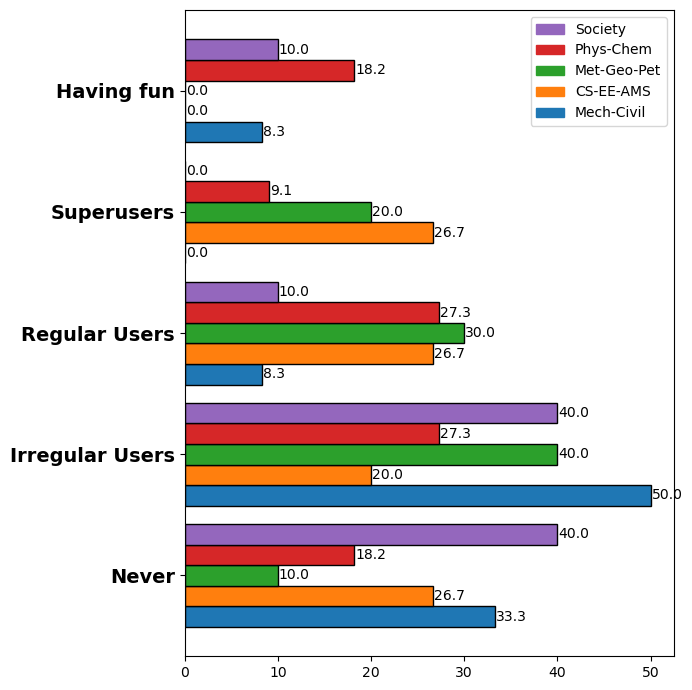

In [383]:
grouped_bar_graph_horizontal_color(categories, mech_civil, cs_ee_ams, met_geo_pet, phys_chem, society, 'Frequency of using LLM-powered Chatbots',7,7) # size 7X7, font 16

In [50]:
years_at_mines_faculty = df_new["How many years have you been at Mines?"]

In [51]:
years_at_mines_faculty.value_counts()

How many years have you been at Mines?
1-5 years         26
10-20 years       24
5-10 years        22
1 year or less    12
> 20 years         9
Name: count, dtype: int64

In [52]:
ins_exp = df_new["How many years of full-time industry experience (i.e. public or private sector work outside of academia but within your current discipline) did you obtain in your field prior to beginning your role at Mines? (Please do not include internships or part-time roles.)"]

In [53]:
ins_exp.value_counts()

How many years of full-time industry experience (i.e. public or private sector work outside of academia but within your current discipline) did you obtain in your field prior to beginning your role at Mines? (Please do not include internships or part-time roles.)
1-5 years         21
10-20 years       13
5-10 years        12
> 20 years         8
1 year or less     7
Name: count, dtype: int64

In [57]:
count = 0
for val in ins_exp:
    if pd.isna(val):
        count += 1
print(count)
    

34


In [58]:
# RQ4

In [123]:
spring_course = df_new["Did you teach at least one course during Spring 2023?"]

In [60]:
spring_course.value_counts()

Did you teach at least one course during Spring 2023?
Yes    60
No     35
Name: count, dtype: int64

In [63]:
fall_course = df_new["How many unique courses are you teaching during Fall 2023? For example, if you are teaching 1 course with 3 sections, please select \"1.\" If you are teaching 2 different courses, 1 with 2 sections, the other with 1 section, please select \"2.\""]

In [70]:
fall_course.value_counts()

How many unique courses are you teaching during Fall 2023? For example, if you are teaching 1 course with 3 sections, please select "1." If you are teaching 2 different courses, 1 with 2 sections, the other with 1 section, please select "2."
1.0    34
2.0    30
0.0    21
3.0     8
4.0     2
Name: count, dtype: int64

spring_policy = df_new["For the course(s) you taught during Spring 2023, to what degree did you provide guidance to students on GenAI?"]

In [69]:
spring_policy.value_counts()/ 60 * 100

For the course(s) you taught during Spring 2023, to what degree did you provide guidance to students on GenAI?
Did not provide any guidance                                                             61.666667
Loose guidance mentioned in class, but no formal policy statement                        23.333333
Stated a policy in class or on the course website that was not listed on the syllabus    10.000000
Formal policy in at least one syllabus                                                    5.000000
Name: count, dtype: float64

In [92]:
class1 = df_new["Class 1: To what degree have you provided guidance to students on GenAI in this class?"]
class2 = df_new["Class 2: To what degree have you provided guidance to students on GenAI in this class?"]
class3 = df_new["Class 3: To what degree have you provided guidance to students on GenAI in this class?"]
class4 = df_new["Class 4: To what degree have you provided guidance to students on GenAI in this class?"]

In [72]:
class1.value_counts()

Class 1: To what degree have you provided guidance to students on GenAI in this class?
Formal policy in the syllabus using language recommended by the Provost's Office          45
No guidance specific to GenAI has been provided yet                                       14
Loose guidance mentioned in class, but no formal statement of policy                       6
Formal policy in the syllabus that was not provided by the Provost's Office                5
Formal policy was stated in class or on the course website, but not listed in syllabus     4
Name: count, dtype: int64

In [73]:
filtered = df_new[fall_course == 1]

In [74]:
# Get value counts of class1 for these rows
print(filtered["Class 1: To what degree have you provided guidance to students on GenAI in this class?"].value_counts(dropna=False))

Class 1: To what degree have you provided guidance to students on GenAI in this class?
Formal policy in the syllabus using language recommended by the Provost's Office          20
No guidance specific to GenAI has been provided yet                                        7
Formal policy in the syllabus that was not provided by the Provost's Office                3
Formal policy was stated in class or on the course website, but not listed in syllabus     2
Loose guidance mentioned in class, but no formal statement of policy                       2
Name: count, dtype: int64


In [81]:
filtered = df_new[(fall_course == 2)]

In [82]:
print(filtered["Class 1: To what degree have you provided guidance to students on GenAI in this class?"].value_counts(dropna=False))

Class 1: To what degree have you provided guidance to students on GenAI in this class?
Formal policy in the syllabus using language recommended by the Provost's Office          19
No guidance specific to GenAI has been provided yet                                        5
Formal policy in the syllabus that was not provided by the Provost's Office                2
Formal policy was stated in class or on the course website, but not listed in syllabus     2
Loose guidance mentioned in class, but no formal statement of policy                       2
Name: count, dtype: int64


In [83]:
print(filtered["Class 2: To what degree have you provided guidance to students on GenAI in this class?"].value_counts(dropna=False))

Class 2: To what degree have you provided guidance to students on GenAI in this class?
Formal policy in the syllabus using language recommended by the Provost's Office    16
No guidance specific to GenAI has been provided yet                                 11
Formal policy in the syllabus that was not provided by the Provost's Office          2
Loose guidance mentioned in class, but no formal statement of policy                 1
Name: count, dtype: int64


In [84]:
filtered = df_new[(fall_course == 3)]

In [85]:
print(filtered["Class 1: To what degree have you provided guidance to students on GenAI in this class?"].value_counts(dropna=False))

Class 1: To what degree have you provided guidance to students on GenAI in this class?
Formal policy in the syllabus using language recommended by the Provost's Office    5
No guidance specific to GenAI has been provided yet                                 2
Loose guidance mentioned in class, but no formal statement of policy                1
Name: count, dtype: int64


In [86]:
print(filtered["Class 2: To what degree have you provided guidance to students on GenAI in this class?"].value_counts(dropna=False))

Class 2: To what degree have you provided guidance to students on GenAI in this class?
Formal policy in the syllabus using language recommended by the Provost's Office    5
No guidance specific to GenAI has been provided yet                                 2
Loose guidance mentioned in class, but no formal statement of policy                1
Name: count, dtype: int64


In [87]:
print(filtered["Class 3: To what degree have you provided guidance to students on GenAI in this class?"].value_counts(dropna=False))

Class 3: To what degree have you provided guidance to students on GenAI in this class?
Formal policy in the syllabus using language recommended by the Provost's Office    4
Loose guidance mentioned in class, but no formal statement of policy                2
No guidance specific to GenAI has been provided yet                                 2
Name: count, dtype: int64


In [88]:
aware_guidance = df_new["To what degree are you aware of the Mines-wide guidance that was issued by the Office of the Provost over email in August 2023? Please select all that apply:"]

In [89]:
aware_guidance.value_counts()

To what degree are you aware of the Mines-wide guidance that was issued by the Office of the Provost over email in August 2023? Please select all that apply:
0                                                      85
I am unaware of any institutional guidance on GenAI    10
Name: count, dtype: int64

In [90]:
class1.value_counts()

Class 1: To what degree have you provided guidance to students on GenAI in this class?
Formal policy in the syllabus using language recommended by the Provost's Office          45
No guidance specific to GenAI has been provided yet                                       14
Loose guidance mentioned in class, but no formal statement of policy                       6
Formal policy in the syllabus that was not provided by the Provost's Office                5
Formal policy was stated in class or on the course website, but not listed in syllabus     4
Name: count, dtype: int64

In [93]:
class2.value_counts()

Class 2: To what degree have you provided guidance to students on GenAI in this class?
Formal policy in the syllabus using language recommended by the Provost's Office    21
No guidance specific to GenAI has been provided yet                                 15
Formal policy in the syllabus that was not provided by the Provost's Office          2
Loose guidance mentioned in class, but no formal statement of policy                 2
Name: count, dtype: int64

In [94]:
class3.value_counts()

Class 3: To what degree have you provided guidance to students on GenAI in this class?
Formal policy in the syllabus using language recommended by the Provost's Office    5
No guidance specific to GenAI has been provided yet                                 3
Loose guidance mentioned in class, but no formal statement of policy                2
Name: count, dtype: int64

In [95]:
class4.value_counts()

Class 4: To what degree have you provided guidance to students on GenAI in this class?
No guidance specific to GenAI has been provided yet                                 1
Formal policy in the syllabus using language recommended by the Provost's Office    1
Name: count, dtype: int64

In [104]:
# RQ4 -> Need re-analyze everything by not considering admitrative faculty as they didn't conduct any courses. More over, course order doesn't matter for those faculty whi took more than one unique course

In [107]:
role.value_counts()

What is your current role at Mines?
Administrative faculty                        16
Tenure track faculty  Full professor         16
Teaching faculty  Full professor             13
Adjunct faculty                               10
Tenure track faculty  Associate professor     9
Tenure track faculty  Assistant professor     8
Teaching faculty  Associate professor         8
Teaching faculty  Assistant professor         6
Postdoctoral staff or research faculty         4
Other (Please specify)                         2
Professor of practice                          2
Name: count, dtype: int64

In [116]:
filtered = df_new[~role.isin(["Administrative faculty", "Other (Please specify)"])]

In [117]:
role_filtered = filtered["What is your current role at Mines?"]
role_filtered.value_counts()

What is your current role at Mines?
Tenure track faculty  Full professor         16
Teaching faculty  Full professor             13
Adjunct faculty                               10
Tenure track faculty  Associate professor     9
Tenure track faculty  Assistant professor     8
Teaching faculty  Associate professor         8
Teaching faculty  Assistant professor         6
Postdoctoral staff or research faculty         4
Professor of practice                          2
Name: count, dtype: int64

In [118]:
role_filtered.value_counts().sum()

76

In [119]:
spring_course_fil = filtered["Did you teach at least one course during Spring 2023?"]

In [134]:
spring_course_fil.value_counts() 

Did you teach at least one course during Spring 2023?
Yes    58
No     19
Name: count, dtype: int64

In [130]:
for i in range(len(spring_course)):
    print(response_id.iloc[i])
    print(role.iloc[i])
    print(spring_course.iloc[i])
    print("\n")

114801644.0
Tenure track faculty  Associate professor
No


114801654.0
Administrative faculty
No


114801670.0
Administrative faculty
No


114801704.0
Teaching faculty  Full professor
Yes


114801762.0
Tenure track faculty  Full professor
No


114801781.0
Tenure track faculty  Assistant professor
Yes


114801906.0
Other (Please specify)
No


114801956.0
Administrative faculty
No


114802421.0
Administrative faculty
No


114802480.0
Administrative faculty
No


114802630.0
Postdoctoral staff or research faculty
No


114802886.0
Teaching faculty  Associate professor
Yes


114803243.0
Tenure track faculty  Assistant professor
Yes


114803641.0
Teaching faculty  Associate professor
Yes


114803953.0
Tenure track faculty  Assistant professor
Yes


114804279.0
Tenure track faculty  Associate professor
Yes


114804700.0
Teaching faculty  Assistant professor
Yes


114807076.0
Adjunct faculty
Yes


114807181.0
Administrative faculty
No


114807503.0
Administrative faculty
No


11480867

In [125]:
fall_course_fil = filtered["How many unique courses are you teaching during Fall 2023? For example, if you are teaching 1 course with 3 sections, please select \"1.\" If you are teaching 2 different courses, 1 with 2 sections, the other with 1 section, please select \"2.\""]

In [139]:
fall_course_fil.value_counts()

How many unique courses are you teaching during Fall 2023? For example, if you are teaching 1 course with 3 sections, please select "1." If you are teaching 2 different courses, 1 with 2 sections, the other with 1 section, please select "2."
2.0    30
1.0    29
0.0     9
3.0     7
4.0     2
Name: count, dtype: int64

In [127]:
fall_course_fil.value_counts().sum()

77

In [131]:
spring_policy_fil = filtered["For the course(s) you taught during Spring 2023, to what degree did you provide guidance to students on GenAI?"]

In [137]:
spring_policy_fil.value_counts() / 58 * 100

For the course(s) you taught during Spring 2023, to what degree did you provide guidance to students on GenAI?
Did not provide any guidance                                                             60.344828
Loose guidance mentioned in class, but no formal policy statement                        24.137931
Stated a policy in class or on the course website that was not listed on the syllabus    10.344828
Formal policy in at least one syllabus                                                    5.172414
Name: count, dtype: float64

In [138]:
class1 = filtered["Class 1: To what degree have you provided guidance to students on GenAI in this class?"]
class2 = filtered["Class 2: To what degree have you provided guidance to students on GenAI in this class?"]
class3 = filtered["Class 3: To what degree have you provided guidance to students on GenAI in this class?"]
class4 = filtered["Class 4: To what degree have you provided guidance to students on GenAI in this class?"]

In [140]:
res = filtered["Response ID"]
print(len(res))

77


In [142]:
fil2 = filtered[fall_course_fil == 1]

In [143]:
print(fil2["Class 1: To what degree have you provided guidance to students on GenAI in this class?"].value_counts())

Class 1: To what degree have you provided guidance to students on GenAI in this class?
Formal policy in the syllabus using language recommended by the Provost's Office          19
No guidance specific to GenAI has been provided yet                                        4
Formal policy in the syllabus that was not provided by the Provost's Office                3
Loose guidance mentioned in class, but no formal statement of policy                       2
Formal policy was stated in class or on the course website, but not listed in syllabus     1
Name: count, dtype: int64


In [147]:
formal_recommended = "Formal policy in the syllabus using language recommended by the Provost's Office"
formal_own = "Formal policy in the syllabus that was not provided by the Provost's Office"
formal_other = "Formal policy was stated in class or on the course website, but not listed in syllabus"
informal = "Loose guidance mentioned in class, but no formal statement of policy"
none = "No guidance specific to GenAI has been provided yet"


In [144]:
fil2 = filtered[fall_course_fil == 2]

In [145]:
print(fil2["Class 1: To what degree have you provided guidance to students on GenAI in this class?"].value_counts())

Class 1: To what degree have you provided guidance to students on GenAI in this class?
Formal policy in the syllabus using language recommended by the Provost's Office          19
No guidance specific to GenAI has been provided yet                                        5
Formal policy in the syllabus that was not provided by the Provost's Office                2
Formal policy was stated in class or on the course website, but not listed in syllabus     2
Loose guidance mentioned in class, but no formal statement of policy                       2
Name: count, dtype: int64


In [146]:
print(fil2["Class 2: To what degree have you provided guidance to students on GenAI in this class?"].value_counts())

Class 2: To what degree have you provided guidance to students on GenAI in this class?
Formal policy in the syllabus using language recommended by the Provost's Office    16
No guidance specific to GenAI has been provided yet                                 11
Formal policy in the syllabus that was not provided by the Provost's Office          2
Loose guidance mentioned in class, but no formal statement of policy                 1
Name: count, dtype: int64


In [202]:
fil2 = filtered[(fall_course_fil == 1) | (fall_course_fil == 2) | (fall_course_fil == 3) | (fall_course_fil == 4)]

In [204]:
res2 = fil2["Response ID"]
print(len(res2))

68


In [205]:
class1_level = fil2["Class 1: What is the level of this course?"]
class2_level = fil2["Class 2: What is the level of this course?"]
class3_level = fil2["Class 3: What is the level of this course?"]
class4_level = fil2["Class 4: What is the level of this course?"]

In [249]:
# Initialize counters
frec = 0      # Formal - Provost syllabus
fown = 0      # Formal - own syllabus
fother = 0    # Formal - in-class/website
info_only = 0 # Informal guidance only
none_count = 0  # No guidance at all
not_res = 0
not_res_vec = []
# Constants (your original strings)
formal_recommended = "Formal policy in the syllabus using language recommended by the Provost's Office"
formal_own = "Formal policy in the syllabus that was not provided by the Provost's Office"
formal_other = "Formal policy was stated in class or on the course website, but not listed in syllabus"
informal = "Loose guidance mentioned in class, but no formal statement of policy"
none = "No guidance specific to GenAI has been provided yet"

# Loop through faculty
for i in range(len(res2)):
    
    responses = [class1.iloc[i], class2.iloc[i], class3.iloc[i], class4.iloc[i]]
    responses_clean = [r for r in responses if pd.notna(r)]
    if len(responses_clean) == 0:
        not_res += 1
        not_res_vec.append(res2.iloc[i])
    course_level = [class1_level.iloc[i], class2_level.iloc[i], class3_level.iloc[i], class4_level.iloc[i]]
    #print(res.iloc[i])
    #print(responses)
    # First check for formal types (priority)
    if formal_recommended in responses_clean:
        frec += 1
    elif formal_own in responses_clean:
        fown += 1
    elif formal_other in responses_clean:
        fother += 1
    elif len(responses_clean) > 0 and all(r == informal for r in responses_clean):
        info_only += 1
        #print(course_level)
    elif len(responses_clean) > 0 and all(r == none for r in responses_clean):
        none_count += 1
    else:
        if informal in responses_clean:
            info_only += 1


In [250]:
print(frec)
print(fown)
print(fother)
print(info_only)
print(none_count)
print(not_res)
print(not_res_vec)

39
6
2
6
8
7
[114802886.0, 114808670.0, 114809188.0, 114812414.0, 114867495.0, 114960372.0, 115452781.0]


In [215]:
total = len(res2)
total_formal = frec + fown + fother
pct_formal = total_formal / total * 100
pct_frec = frec / total * 100
pct_fown = fown / total * 100
pct_fother = fother / total * 100
pct_info = info_only / total * 100
pct_none = none_count / total * 100

In [216]:
print(f"{pct_formal:.1f}% of faculty gave some form of formal GenAI guidance in at least one course they taught:")
print(f"  - {pct_frec:.1f}% used Provost’s Office language in their syllabus")
print(f"  - {pct_fown:.1f}% used their own syllabus language")
print(f"  - {pct_fother:.1f}% gave formal guidance outside the syllabus (e.g., in class or online)")

print(f"{pct_info:.1f}% gave only informal guidance in all courses")
print(f"{pct_none:.1f}% gave no GenAI-related guidance in any of their courses")


69.1% of faculty gave some form of formal GenAI guidance in at least one course they taught:
  - 57.4% used Provost’s Office language in their syllabus
  - 8.8% used their own syllabus language
  - 2.9% gave formal guidance outside the syllabus (e.g., in class or online)
8.8% gave only informal guidance in all courses
11.8% gave no GenAI-related guidance in any of their courses


In [218]:
# Aware Vs Guidance

In [219]:
unaware = fil2["To what degree are you aware of the Mines-wide guidance that was issued by the Office of the Provost over email in August 2023? Please select all that apply:"]

In [220]:
unaware.value_counts()

To what degree are you aware of the Mines-wide guidance that was issued by the Office of the Provost over email in August 2023? Please select all that apply:
0                                                      63
I am unaware of any institutional guidance on GenAI     5
Name: count, dtype: int64

In [222]:
saw_email = fil2["Unnamed: 40"]
saw_email.value_counts()

Unnamed: 40
I saw the email from the Provosts email    49
0                                           19
Name: count, dtype: int64

In [223]:
read_guidelines_email = fil2["Unnamed: 41"]
read_guidelines_email.value_counts()

Unnamed: 41
I read the guidelines provided in the email    51
0                                              17
Name: count, dtype: int64

In [226]:
read_lan_syl_tem = fil2["Unnamed: 42"]
read_lan_syl_tem.value_counts()

Unnamed: 42
I have read the language on GenAI in the new syllabus template    50
0                                                                 18
Name: count, dtype: int64

In [227]:
visit_trefny = fil2["Unnamed: 43"]
visit_trefny.value_counts()

Unnamed: 43
0                                                   38
I have visited the Trefny Centers resource page    30
Name: count, dtype: int64

In [229]:
guidance_binary = []  # 1 = gave formal guidance in any course, 0 = only informal or none

for i in range(len(res2)):
    responses = [class1.iloc[i], class2.iloc[i], class3.iloc[i], class4.iloc[i]]
    responses_clean = [r for r in responses if pd.notna(r)]

    if formal_recommended in responses_clean or formal_own in responses_clean or formal_other in responses_clean:
        guidance_binary.append(1)
    elif len(responses_clean) > 0 and all(r in [informal, none] for r in responses_clean):
        guidance_binary.append(0)
    elif len(responses_clean) == 0:
        guidance_binary.append(0)  # optionally exclude these or set as 0


In [236]:
pd.Series(guidance_binary).value_counts()

1    47
0    21
Name: count, dtype: int64

In [241]:
del str  # Restore built-in str type

In [243]:
unaware_binary = unaware.apply(lambda x: 1 if isinstance(x, str) and "unaware" in x.lower() else 0)
saw_email_binary = saw_email.apply(lambda x: 1 if isinstance(x, str) and "email" in x.lower() else 0)
read_guidelines_binary = fil2["Unnamed: 41"].apply(lambda x: 1 if isinstance(x, str) and "guidelines" in x.lower() else 0)
syllabus_template_binary = fil2["Unnamed: 42"].apply(lambda x: 1 if isinstance(x, str) and "syllabus" in x.lower() else 0)
trefny_binary = fil2["Unnamed: 43"].apply(lambda x: 1 if isinstance(x, str) and "trefny" in x.lower() else 0)


In [287]:
pd.Series(unaware_binary).value_counts()

To what degree are you aware of the Mines-wide guidance that was issued by the Office of the Provost over email in August 2023? Please select all that apply:
0    63
1     5
Name: count, dtype: int64

In [283]:
df_model = pd.DataFrame({
    "Id": res2,
    "guidance": guidance_binary,
    "unaware": unaware_binary,
    "aware_email": saw_email_binary,
    "aware_read_guidelines": read_guidelines_binary,
    "aware_syllabus_template": syllabus_template_binary,
    "aware_trefny": trefny_binary
})

In [284]:
df_model = df_model[~df_model["Id"].isin(not_res_vec)]


In [292]:
df_model

,Id,guidance,unaware,aware_email,aware_read_guidelines,aware_syllabus_template,aware_trefny
8,114801644.0,0,0,1,0,0,0
11,114801704.0,1,0,1,1,1,0
13,114801762.0,0,0,0,0,0,1
14,114801781.0,1,0,1,1,1,0
31,114803243.0,0,0,1,0,0,0
...,...,...,...,...,...,...,...
134,115458823.0,1,0,1,1,1,1
138,115473179.0,1,0,1,1,1,0
139,115474843.0,1,0,1,1,0,0
140,115488174.0,0,0,1,1,1,1


In [293]:
# Cross-tab of awareness vs guidance
pd.crosstab(df_model["aware_email"], df_model["guidance"])


guidance,0,1
aware_email,,
0,4,12
1,10,35


In [286]:
aware_summary = pd.crosstab(df_model["unaware"], df_model["guidance"], normalize='index') * 100
print(aware_summary)


guidance          0           1
unaware                        
0         24.561404   75.438596
1          0.000000  100.000000


In [279]:
import statsmodels.api as sm

In [280]:
# Define IVs and DV
X = df_model[[ "aware_email", "aware_read_guidelines", "aware_syllabus_template", "aware_trefny"]]
y = df_model["guidance"]

In [281]:
# Add intercept to X
X = sm.add_constant(X)

In [282]:
# Fit logistic regression
model = sm.Logit(y, X)
result = model.fit()

# Output summary
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.530140
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:               guidance   No. Observations:                   61
Model:                          Logit   Df Residuals:                       56
Method:                           MLE   Df Model:                            4
Date:                Wed, 02 Jul 2025   Pseudo R-squ.:                 0.01586
Time:                        16:10:08   Log-Likelihood:                -32.339
converged:                       True   LL-Null:                       -32.860
Covariance Type:            nonrobust   LLR p-value:                    0.9034
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       0.7908      0.680      1.163      0.245      -0.542   

In [294]:
from scipy.stats import fisher_exact

table = [[14, 43],  # Unaware = 0
         [0, 4]]    # Unaware = 1

oddsratio, p_value = fisher_exact(table)
print(f"Fisher's exact test p-value: {p_value:.4f}")

Fisher's exact test p-value: 0.5650


In [295]:
course_levels = pd.DataFrame({
    'class1': class1_level,
    'class2': class2_level,
    'class3': class3_level,
    'class4': class4_level
})

In [296]:
course_levels

,class1,class2,class3,class4
8,Graduate (mostly M.S./Ph.D. students),Graduate (mostly M.S./Ph.D. students),Late undergraduate (mostly third-/fourth-year ...,NaN
11,Early undergraduate (mostly first-/second-year...,NaN,NaN,NaN
13,Graduate (mostly M.S./Ph.D. students),Graduate (mostly M.S./Ph.D. students),NaN,NaN
14,Graduate (mostly M.S./Ph.D. students),NaN,NaN,NaN
29,Late undergraduate (mostly third-/fourth-year ...,NaN,NaN,NaN
...,...,...,...,...
134,Early undergraduate (mostly first-/second-year...,Late undergraduate (mostly third-/fourth-year ...,NaN,NaN
138,Early undergraduate (mostly first-/second-year...,Late undergraduate (mostly third-/fourth-year ...,NaN,NaN
139,Late undergraduate (mostly third-/fourth-year ...,NaN,NaN,NaN
140,Late undergraduate (mostly third-/fourth-year ...,Graduate (mostly M.S./Ph.D. students),NaN,NaN


In [297]:
early_ug = course_levels.apply(lambda row: any("Early undergraduate" in str(val) for val in row), axis=1).astype(int)
late_ug = course_levels.apply(lambda row: any("Late undergraduate" in str(val) for val in row), axis=1).astype(int)
grad = course_levels.apply(lambda row: any("Graduate" in str(val) for val in row), axis=1).astype(int)

In [309]:
grad

8      1
11     0
13     1
14     1
29     0
      ..
134    0
138    0
139    0
140    1
141    1
Length: 68, dtype: int64

In [300]:
unique_course = fil2["How many unique courses are you teaching during Fall 2023? For example, if you are teaching 1 course with 3 sections, please select \"1.\" If you are teaching 2 different courses, 1 with 2 sections, the other with 1 section, please select \"2.\""]

In [301]:
unique_course.value_counts()

How many unique courses are you teaching during Fall 2023? For example, if you are teaching 1 course with 3 sections, please select "1." If you are teaching 2 different courses, 1 with 2 sections, the other with 1 section, please select "2."
2.0    30
1.0    29
3.0     7
4.0     2
Name: count, dtype: int64

In [316]:
df_model2 = pd.DataFrame({
    "guidance": guidance_binary,
    "num_courses": unique_course,
    "early_ug": early_ug,
    "late_ug": late_ug,
    "grad": grad
})


In [317]:
df_model2

,guidance,num_courses,early_ug,late_ug,grad
8,0,3.0,0,1,1
11,1,1.0,1,0,0
13,0,2.0,0,0,1
14,1,1.0,0,0,1
29,0,1.0,0,1,0
...,...,...,...,...,...
134,1,2.0,1,1,0
138,1,2.0,1,1,0
139,1,1.0,0,1,0
140,0,2.0,0,1,1


In [318]:
print(len(guidance_binary))
print(len(unique_course))
print(len(early_ug))
print(len(late_ug))
print(len(grad))


68
68
68
68
68


In [319]:
# Define IVs (excluding one dummy to serve as reference group)
X = df_model2[["num_courses", "early_ug", "late_ug", "grad"]]  
X = sm.add_constant(X)

# DV
y = df_model2["guidance"]

# Fit logistic regression
model = sm.Logit(y, X)
result = model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.567000
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:               guidance   No. Observations:                   68
Model:                          Logit   Df Residuals:                       63
Method:                           MLE   Df Model:                            4
Date:                Thu, 03 Jul 2025   Pseudo R-squ.:                 0.08276
Time:                        13:00:17   Log-Likelihood:                -38.556
converged:                       True   LL-Null:                       -42.035
Covariance Type:            nonrobust   LLR p-value:                    0.1382
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.4148      0.921      2.622      0.009       0.610       4.220
num_courses    -0.8901    

In [340]:
role_fall = fil2["What is your current role at Mines?"]
genai_usage_freq_fall = fil2["Please rate how frequently you have used the following GenAI-based tools for your classes, research, and/or any other professional efforts"]

In [348]:
role_fall.value_counts()

What is your current role at Mines?
Tenure track faculty  Full professor         15
Teaching faculty  Full professor             13
Tenure track faculty  Associate professor     8
Teaching faculty  Associate professor         8
Adjunct faculty                                8
Tenure track faculty  Assistant professor     7
Teaching faculty  Assistant professor         6
Professor of practice                          2
Name: count, dtype: int64

In [341]:
df_model3 = pd.DataFrame({
    "usage": genai_usage_freq_fall,
    "role": role_fall,
    "num_course": unique_course
})

In [342]:
df_model3

,usage,role,num_course
8,Regularly (Once or twice a week),Tenure track faculty  Associate professor,3.0
11,Never,Teaching faculty  Full professor,1.0
13,Never,Tenure track faculty  Full professor,2.0
14,Once or Twice,Tenure track faculty  Assistant professor,1.0
29,Regularly (Once or twice a week),Teaching faculty  Associate professor,1.0
...,...,...,...
134,Regularly (Once or twice a week),Teaching faculty  Associate professor,2.0
138,"All the time (daily, or more often)",Teaching faculty  Associate professor,2.0
139,Never,Tenure track faculty  Full professor,1.0
140,Regularly (Once or twice a week),Tenure track faculty  Full professor,2.0


In [344]:
# Define usage order
from pandas.api.types import CategoricalDtype

usage_order = CategoricalDtype(categories=['Never', 'Have only used for fun or curiosity, never work', 'Once or Twice', 'Regularly (Once or twice a week)', 'All the time (daily, or more often)'], ordered=True)

df_model3['usage'] = df_model3['usage'].astype(usage_order)

In [346]:
df_dummies = pd.get_dummies(df_model3['role'], drop_first=True)  # drop_first avoids multicollinearity
X = pd.concat([df_dummies, df_model3['num_course']], axis=1)


In [347]:
X

,Professor of practice,Teaching faculty  Assistant professor,Teaching faculty  Associate professor,Teaching faculty  Full professor,Tenure track faculty  Assistant professor,Tenure track faculty  Associate professor,Tenure track faculty  Full professor,num_course
8,False,False,False,False,False,True,False,3.0
11,False,False,False,True,False,False,False,1.0
13,False,False,False,False,False,False,True,2.0
14,False,False,False,False,True,False,False,1.0
29,False,False,True,False,False,False,False,1.0
...,...,...,...,...,...,...,...,...
134,False,False,True,False,False,False,False,2.0
138,False,False,True,False,False,False,False,2.0
139,False,False,False,False,False,False,True,1.0
140,False,False,False,False,False,False,True,2.0


In [357]:
usage_order = CategoricalDtype(
    categories=[
        'Never', 
        'Have only used for fun or curiosity, never work', 
        'Once or Twice', 
        'Regularly (Once or twice a week)', 
        'All the time (daily, or more often)'
    ],
    ordered=True
)
df_model3['usage'] = df_model3['usage'].astype(usage_order)

In [365]:
df_model3['usage_code'] = df_model3['usage'].cat.codes


In [366]:
y = df_model3['usage']

In [367]:
y

8         Regularly (Once or twice a week)
11                                   Never
13                                   Never
14                           Once or Twice
29        Regularly (Once or twice a week)
                      ...                 
134       Regularly (Once or twice a week)
138    All the time (daily, or more often)
139                                  Never
140       Regularly (Once or twice a week)
141       Regularly (Once or twice a week)
Name: usage, Length: 68, dtype: category
Categories (5, object): ['Never' < 'Have only used for fun or curiosity, never work' < 'Once or Twice' < 'Regularly (Once or twice a week)' < 'All the time (daily, or more often)']

In [371]:
import pandas as pd
from statsmodels.miscmodels.ordinal_model import OrderedModel
from pandas.api.types import CategoricalDtype

# Define the usage order
usage_order = CategoricalDtype(
    categories=[
        'Never',
        'Have only used for fun or curiosity, never work',
        'Once or Twice',
        'Regularly (Once or twice a week)',
        'All the time (daily, or more often)'
    ],
    ordered=True
)

# Apply ordered category
df_model3['usage'] = df_model3['usage'].astype(usage_order)
df_model3['usage_code'] = df_model3['usage'].cat.codes

# Convert 'role' to dummies and ensure all are numeric
df_dummies = pd.get_dummies(df_model3['role'], drop_first=True).astype(float)

# Ensure num_course is numeric
df_model3['num_course'] = pd.to_numeric(df_model3['num_course'], errors='coerce')

# Combine predictors
X = pd.concat([df_dummies, df_model3['num_course']], axis=1).astype(float)

# Target
y = df_model3['usage_code'].astype(int)

# Fit the model
model = OrderedModel(y, X, distr='logit')
result = model.fit(method='bfgs')  # method required sometimes
print(result.summary())


Optimization terminated successfully.
         Current function value: 1.335716
         Iterations: 57
         Function evaluations: 59
         Gradient evaluations: 59
                             OrderedModel Results                             
Dep. Variable:             usage_code   Log-Likelihood:                -90.829
Model:                   OrderedModel   AIC:                             205.7
Method:            Maximum Likelihood   BIC:                             232.3
Date:                Thu, 03 Jul 2025                                         
Time:                        13:49:04                                         
No. Observations:                  68                                         
Df Residuals:                      56                                         
Df Model:                           8                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
------

In [372]:
print(df_model3.dtypes)
print(df_dummies.dtypes)


usage         category
role            object
num_course     float64
usage_code        int8
dtype: object
Professor of practice                         float64
Teaching faculty  Assistant professor        float64
Teaching faculty  Associate professor        float64
Teaching faculty  Full professor             float64
Tenure track faculty  Assistant professor    float64
Tenure track faculty  Associate professor    float64
Tenure track faculty  Full professor         float64
dtype: object


In [375]:
mines_li = df_new["Which of the following resources would you be likely to use in order to integrate generative AI effectively and responsibly in your role at Mines? (Select all that apply)"]

In [376]:
mines_li.value_counts()

Which of the following resources would you be likely to use in order to integrate generative AI effectively and responsibly in your role at Mines? (Select all that apply)
Mines-wide licensing and ITS support for external GenAI tools (e.g., ChatGPT4+, Git-Hub CoPilot, etc.)    64
0                                                                                                         30
Name: count, dtype: int64

In [377]:
mines_li.value_counts()["Mines-wide licensing and ITS support for external GenAI tools (e.g., ChatGPT4+, Git-Hub CoPilot, etc.)"]

64

In [379]:
custom_imp = df_new["Unnamed: 32"]

In [380]:
custom_imp.value_counts()

Unnamed: 32
0                                                                                                                               67
Custom implementations of internal Mines-owned GenAI tools (e.g., new ITS-supported tools that do not share data externally)    27
Name: count, dtype: int64

In [381]:
tools_idn_ai_con = df_new["Unnamed: 33"]

In [382]:
tools_idn_ai_con.value_counts()

Unnamed: 33
0                                             47
Tools for identifying AI-generated content    47
Name: count, dtype: int64

In [384]:
trefny = df_new["Unnamed: 34"]
trefny.value_counts()

Unnamed: 34
0                                                                                                                                       55
Trefny consultations for developing lesson plans, assessments, and strategies for integrating GenAI in your curriculum or coursework    39
Name: count, dtype: int64

In [385]:
prof_dev_evn = df_new["Unnamed: 35"]
prof_dev_evn.value_counts()

Unnamed: 35
In-person professional development events (e.g., GenAI workshops, roundtables, etc.)    56
0                                                                                       38
Name: count, dtype: int64

In [386]:
online_training = df_new["Unnamed: 36"]
online_training.value_counts()

Unnamed: 36
Online training resources (e.g., online modules or courses on GenAI best practices)    48
0                                                                                      46
Name: count, dtype: int64

In [387]:
mod_tem = df_new["Unnamed: 37"]
mod_tem.value_counts()

Unnamed: 37
0                                                                       49
Modifiable templates for GenAI lessons, assignments, and assessments    46
Name: count, dtype: int64

In [388]:
other = df_new["Unnamed: 38"]
other.value_counts()

Unnamed: 38
0                                                                                               87
The CIARC team hopes to collaborate with Trefny to support the addition of AI in classrooms.     1
I do not see me integrating AI at all at this time.                                              1
none at this time                                                                                1
none                                                                                             1
Advanced courses for training GenAI to custom content. Not just 'gpt for babies'....             1
More computational resources (e.g. more GPUs) would be nice!                                     1
Name: count, dtype: int64

In [401]:
resources = {
    'Mines License': mines_li.value_counts()["Mines-wide licensing and ITS support for external GenAI tools (e.g., ChatGPT4+, Git-Hub CoPilot, etc.)"],
    'Custom Tools': custom_imp.value_counts()["Custom implementations of internal Mines-owned GenAI tools (e.g., new ITS-supported tools that do not share data externally)"],
    'AI Detection Tools': tools_idn_ai_con.value_counts()["Tools for identifying AI-generated content"],
    'Trefny Help': trefny.value_counts()["Trefny consultations for developing lesson plans, assessments, and strategies for integrating GenAI in your curriculum or coursework"],
    'In-person Events': prof_dev_evn.value_counts()["In-person professional development events (e.g., GenAI workshops, roundtables, etc.)"],
    'Online Training': online_training.value_counts()["Online training resources (e.g., online modules or courses on GenAI best practices)"],
    'GenAI Templates': mod_tem.value_counts()["Modifiable templates for GenAI lessons, assignments, and assessments"]
}


In [408]:
resources

{'Mines License': 64,
 'Custom Tools': 27,
 'AI Detection Tools': 47,
 'Trefny Help': 39,
 'In-person Events': 56,
 'Online Training': 48,
 'GenAI Templates': 46}

In [584]:
sorted_resources = dict(sorted(resources.items(), key=lambda item: item[1], reverse=True))
sorted_resources

{'Mines License': 64,
 'In-person Events': 56,
 'Online Training': 48,
 'AI Detection Tools': 47,
 'GenAI Templates': 46,
 'Trefny Help': 39,
 'Custom Tools': 27}

In [590]:
normalized_resources = {k: round(((v/95) * 100), 1) for k, v in sorted_resources.items()}
normalized_resources

{'Mines License': 67.4,
 'In-person Events': 58.9,
 'Online Training': 50.5,
 'AI Detection Tools': 49.5,
 'GenAI Templates': 48.4,
 'Trefny Help': 41.1,
 'Custom Tools': 28.4}

/var/folders/v7/gphzyn511m1_qjvs14t04n000000gn/T/ipykernel_50570/1680264997.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=data.index, y=data.values, palette="Blues_d")


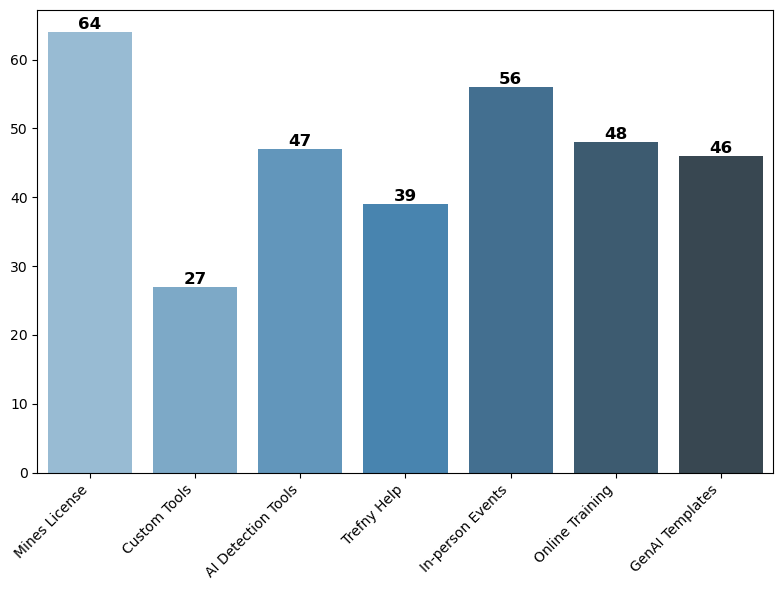

In [403]:
#res = resources.value_counts().sort_values(ascending=False)
draw_barplot(pd.Series(resources), "", "")

In [593]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.font_manager import FontProperties

def draw_barplot2(data, xlabel, ylabel):
    plt.figure(figsize=(8, 6))
    ax = sns.barplot(y=data.index, x=data.values, palette="Blues_d")

    # Annotate bars
    for p in ax.patches:
        ax.annotate(f'{p.get_width():.1f}',  
                    (p.get_width(), p.get_y() + p.get_height() / 2),
                    ha='left', va='center', fontsize=12, color='black', fontweight='bold')

    ax.tick_params(axis='y', labelsize=11, labelcolor='black')
    for tick in ax.get_yticklabels():
        tick.set_fontweight('bold')
    # Define bold font properties
    bold_font = FontProperties()
    bold_font.set_weight('bold')
    bold_font.set_size(12)

    # Apply bold font to axis labels
    ax.set_xlabel(xlabel, fontproperties=bold_font)
    ax.set_ylabel(ylabel, fontproperties=bold_font)

    plt.tight_layout()
    plt.savefig('/Users/jesanahammed/Desktop/faculty_preparedness.png', dpi=300)
    plt.show()


/var/folders/v7/gphzyn511m1_qjvs14t04n000000gn/T/ipykernel_50570/1831596787.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(y=data.index, x=data.values, palette="Blues_d")


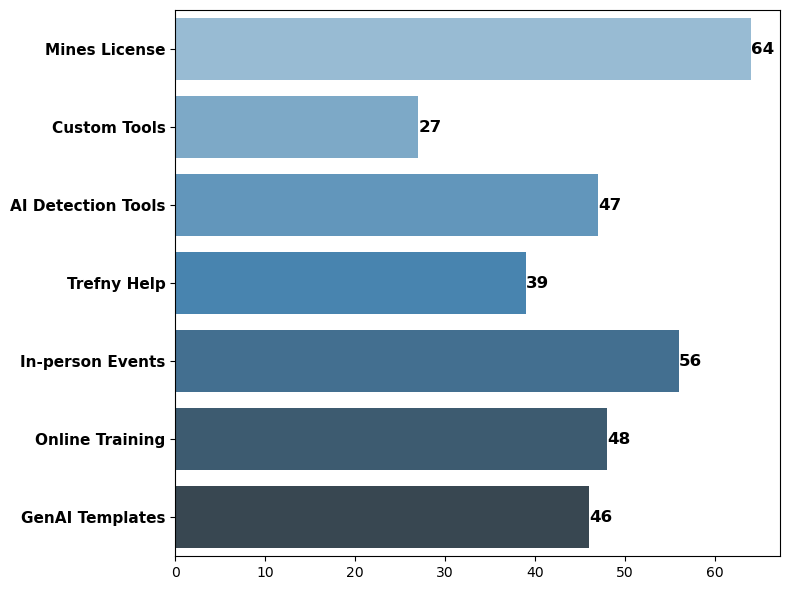

In [591]:
draw_barplot2(pd.Series(resources), "", "")

/var/folders/v7/gphzyn511m1_qjvs14t04n000000gn/T/ipykernel_50570/2237919878.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(y=data.index, x=data.values, palette="Blues_d")


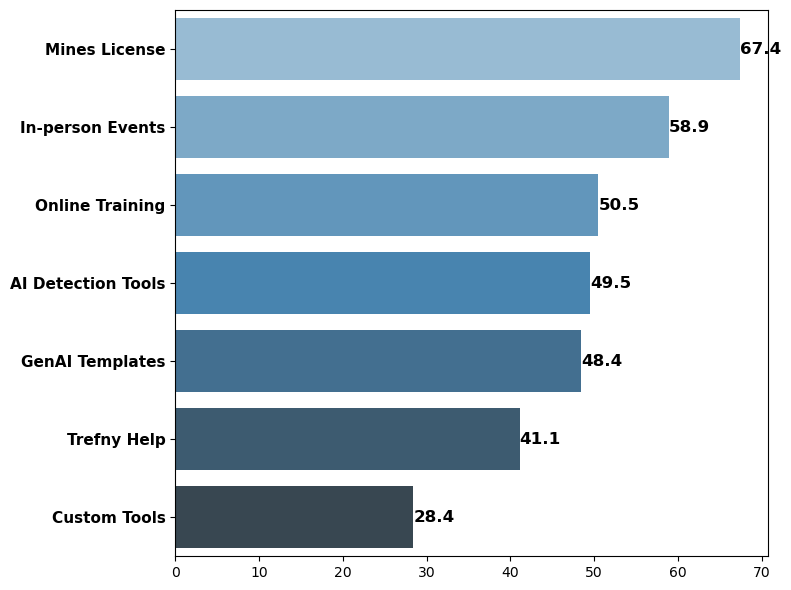

In [594]:
draw_barplot2(pd.Series(normalized_resources), "", "")

In [410]:
def createDataframe(a1, v1, a2, v2):
    df = pd.DataFrame({
       a1: v1,
       a2: v2 
    })

    return df

In [411]:
df = createDataframe('mines_license', mines_li, 'inperson_event', prof_dev_evn)

In [434]:
df


,mines_license,inperson_event
8,Mines-wide licensing and ITS support for exter...,0
9,0,In-person professional development events (e.g...
10,Mines-wide licensing and ITS support for exter...,In-person professional development events (e.g...
11,0,0
13,0,0
...,...,...
137,0,0
138,Mines-wide licensing and ITS support for exter...,0
139,Mines-wide licensing and ITS support for exter...,0
140,Mines-wide licensing and ITS support for exter...,In-person professional development events (e.g...


In [435]:
# Create boolean masks
def npArray(a1, a2, v1, v2):
    both_yes = ((df[a1] == v1) & (df[a2] == v2)).sum()
    a1_only = ((df[a1] == v1) & (df[a2] == '0')).sum()
    a2_only = ((df[a1] == '0') & (df[a2] == v2)).sum()
    neither = ((df[a1] == '0') & (df[a2] == '0')).sum()
    table = np.array([[both_yes, a1_only],
                  [a2_only, neither]])
    return table
    


In [436]:
v1 = "Mines-wide licensing and ITS support for external GenAI tools (e.g., ChatGPT4+, Git-Hub CoPilot, etc.)"
v2 = "In-person professional development events (e.g., GenAI workshops, roundtables, etc.)"

In [437]:
table = npArray('mines_license', 'inperson_event', v1, v2)

In [438]:
print(table)

[[40 24]
 [16 14]]


In [439]:
from statsmodels.stats.contingency_tables import mcnemar
def McNemarTest(table):
    result = mcnemar(table, exact=True)
    print(f"McNemar’s p-value: {result.pvalue:.4f}")
    

In [440]:
McNemarTest(table)

McNemar’s p-value: 0.2682


In [451]:
resources

{'Mines License': 64,
 'Custom Tools': 27,
 'AI Detection Tools': 47,
 'Trefny Help': 39,
 'In-person Events': 56,
 'Online Training': 48,
 'GenAI Templates': 46}

In [579]:
df = pd.DataFrame({
    'Mines License': mines_li,
    'Custom Tools': custom_imp,
    'AI Detection Tools': tools_idn_ai_con,
    'Trefny Help': trefny,
    'In-person Events': prof_dev_evn,
    'Online Training': online_training,
    'GenAI Templates': mod_tem
})

In [580]:
num_unique_participants = df.notna().any(axis=1).sum()
print(num_unique_participants)

95


In [453]:
labels_dict = {
    'Mines License': "Mines-wide licensing and ITS support for external GenAI tools (e.g., ChatGPT4+, Git-Hub CoPilot, etc.)",
    'Custom Tools': "Custom implementations of internal Mines-owned GenAI tools (e.g., new ITS-supported tools that do not share data externally)",
    'AI Detection Tools': "Tools for identifying AI-generated content",
    'Trefny Help': "Trefny consultations for developing lesson plans, assessments, and strategies for integrating GenAI in your curriculum or coursework",
    'In-person Events': "In-person professional development events (e.g., GenAI workshops, roundtables, etc.)",
    'Online Training': "Online training resources (e.g., online modules or courses on GenAI best practices)",
    'GenAI Templates': "Modifiable templates for GenAI lessons, assignments, and assessments"
}

In [454]:
def clean_column(df, col):
    """Fill NaN and convert to binary string labels"""
    return df[col].fillna("0").astype(str)

In [455]:
def compute_mcnemar_table(col1, col2, v1, v2):
    """Create a 2x2 contingency table for McNemar test"""
    both_yes = ((col1 == v1) & (col2 == v2)).sum()
    a1_only  = ((col1 == v1) & (col2 == "0")).sum()
    a2_only  = ((col1 == "0") & (col2 == v2)).sum()
    neither  = ((col1 == "0") & (col2 == "0")).sum()
    return np.array([[both_yes, a1_only], [a2_only, neither]])

In [456]:
def run_mcnemar_tests(df, labels_dict):
    cols = list(labels_dict.keys())
    labels = list(labels_dict.values())
    
    # Prepare p-value matrix
    p_matrix = pd.DataFrame(np.ones((len(cols), len(cols))), columns=cols, index=cols)

    # Compare each pair
    for i, col1 in enumerate(cols):
        for j, col2 in enumerate(cols):
            if i >= j:  # skip redundant pairs and self-comparison
                continue

            c1 = clean_column(df, col1)
            c2 = clean_column(df, col2)

            table = compute_mcnemar_table(c1, c2, labels_dict[col1], labels_dict[col2])

            try:
                result = mcnemar(table, exact=True)
                p_matrix.loc[col1, col2] = result.pvalue
                p_matrix.loc[col2, col1] = result.pvalue
            except Exception as e:
                print(f"Error comparing {col1} vs {col2}: {e}")
    
    return p_matrix

In [457]:
def plot_heatmap(p_matrix, title="McNemar Test P-Value Heatmap"):
    plt.figure(figsize=(10, 8))
    sns.heatmap(p_matrix, annot=True, fmt=".3f", cmap="Blues", cbar_kws={"label": "p-value"},
                linewidths=0.5, linecolor='gray', square=True)
    plt.title(title, fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

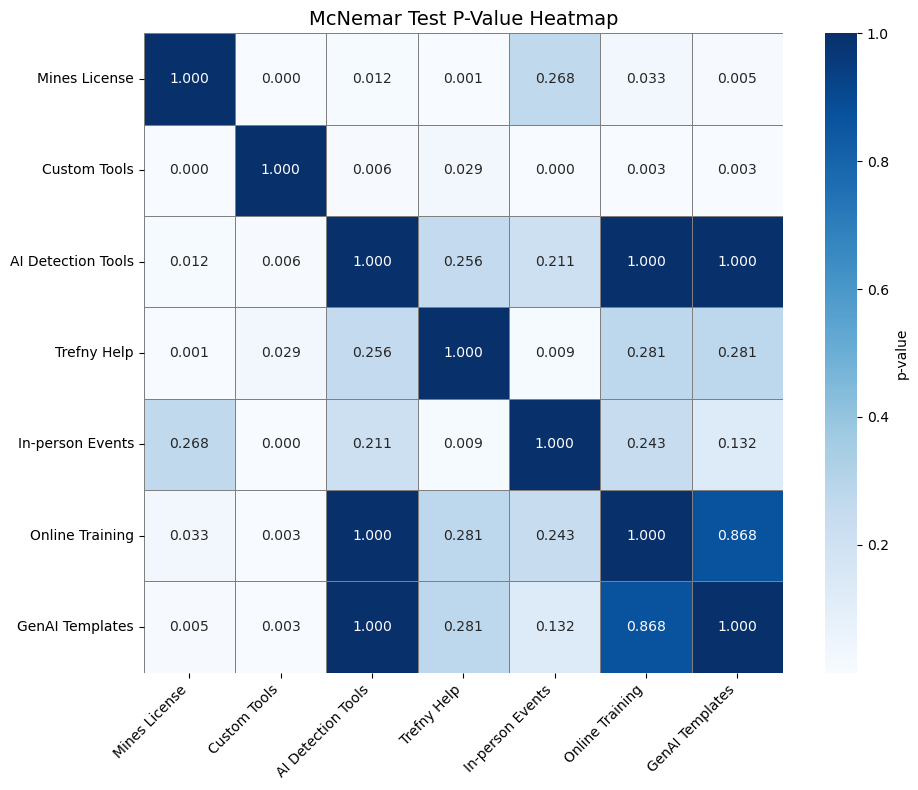

In [458]:
# Run McNemar tests
p_matrix = run_mcnemar_tests(df, labels_dict)

# Plot heatmap
plot_heatmap(p_matrix)

In [448]:
print(p_matrix)

                 mines_license  custom_tools  tools_id    trefny  \
mines_license     1.000000e+00  1.211526e-07  0.011508  0.000621   
custom_tools      1.211526e-07  1.000000e+00  0.005515  0.028959   
tools_id          1.150779e-02  5.515201e-03  1.000000  0.255875   
trefny            6.210435e-04  2.895927e-02  0.255875  1.000000   
inperson_event    2.681873e-01  1.537409e-05  0.211024  0.009475   
online_training   3.283914e-02  3.087676e-03  1.000000  0.280610   
mod_templates     5.097643e-03  3.377848e-03  1.000000  0.281042   

                 inperson_event  online_training  mod_templates  
mines_license          0.268187         0.032839       0.005098  
custom_tools           0.000015         0.003088       0.003378  
tools_id               0.211024         1.000000       1.000000  
trefny                 0.009475         0.280610       0.281042  
inperson_event         1.000000         0.242985       0.132498  
online_training        0.242985         1.000000       0.86

In [461]:
def plot_heatmap2(p_matrix, title=""):
    import seaborn as sns
    import matplotlib.pyplot as plt
    import numpy as np

    plt.figure(figsize=(10, 8))

    # Format: scientific notation for very small p-values
    def fmt_func(x):
        return f"{x:.2e}" if x < 0.001 else f"{x:.3f}"

    sns.heatmap(p_matrix, 
                annot=p_matrix.applymap(fmt_func), 
                fmt='', cmap="Blues", 
                cbar_kws={"label": "p-value"},
                linewidths=0.5, linecolor='gray', square=True)

    plt.title(title, fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


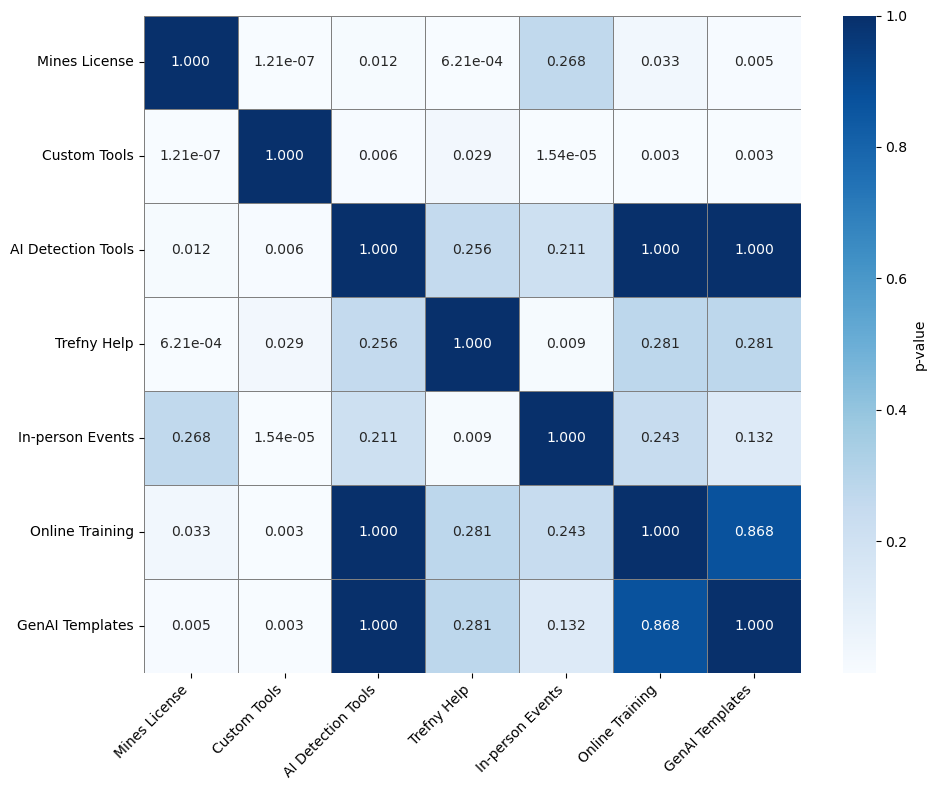

In [462]:
plot_heatmap2(p_matrix)

In [463]:
def bonferroni_correct(p_matrix):
    from itertools import combinations
    corrected = p_matrix.copy()

    # Get number of unique comparisons (above diagonal)
    n = int((len(p_matrix) * (len(p_matrix) - 1)) / 2)

    # Apply Bonferroni correction to all off-diagonal p-values
    for i in range(len(corrected)):
        for j in range(len(corrected)):
            if i != j:
                p = corrected.iloc[i, j]
                corrected.iloc[i, j] = min(p * n, 1.0)

    return corrected


In [464]:
p_corrected = bonferroni_correct(p_matrix)


In [495]:
def plot_significance_heatmap(p_matrix, corrected_matrix, alpha=0.0024):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    plt.figure(figsize=(10, 8))

    # Generate annotations with significance
    annotations = p_matrix.copy().astype(str)
    for i in range(len(p_matrix)):
        for j in range(len(p_matrix)):
            pval = p_matrix.iloc[i, j]
            sig = corrected_matrix.iloc[i, j] < alpha and i != j
            if pval < 0.001:
                label = "p<.001"
            else:
                label = f"{pval:.3f}"
            annotations.iloc[i, j] = f"{label}{'*' if sig else ''}"

    sns.heatmap(p_matrix, 
                annot=annotations, fmt='',
                cmap="Blues", cbar_kws={"label": "Uncorrected p-value"},
                linewidths=0.5, linecolor='gray', square=True)

    plt.title("")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('/Users/jesanahammed/Desktop/p_value.png', dpi=300)
    plt.show()


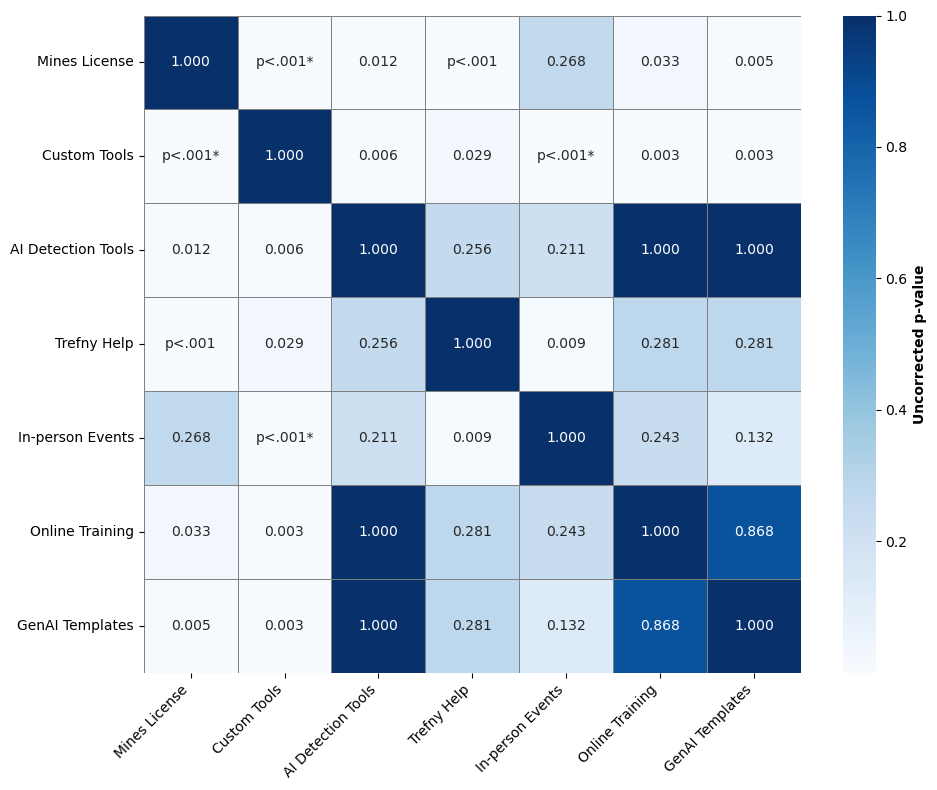

In [496]:
plot_significance_heatmap(p_matrix, p_corrected)


In [470]:
print(p_corrected)

                    Mines License  Custom Tools  AI Detection Tools  \
Mines License            1.000000      0.000003            0.241664   
Custom Tools             0.000003      1.000000            0.115819   
AI Detection Tools       0.241664      0.115819            1.000000   
Trefny Help              0.013042      0.608145            1.000000   
In-person Events         1.000000      0.000323            1.000000   
Online Training          0.689622      0.064841            1.000000   
GenAI Templates          0.107051      0.070935            1.000000   

                    Trefny Help  In-person Events  Online Training  \
Mines License          0.013042          1.000000         0.689622   
Custom Tools           0.608145          0.000323         0.064841   
AI Detection Tools     1.000000          1.000000         1.000000   
Trefny Help            1.000000          0.198981         1.000000   
In-person Events       0.198981          1.000000         1.000000   
Online Trai

In [497]:
df_long = pd.DataFrame({
    'role': role
})

In [498]:
df_long

,role
8,Tenure track faculty  Associate professor
9,Administrative faculty
10,Administrative faculty
11,Teaching faculty  Full professor
13,Tenure track faculty  Full professor
...,...
137,Tenure track faculty  Full professor
138,Teaching faculty  Associate professor
139,Tenure track faculty  Full professor
140,Tenure track faculty  Full professor


In [535]:
df_rename = df_new.rename(columns={
    'Unnamed: 37': 'Modifiable templates for GenAI lessons, assignments, and assessments',
    'Unnamed: 36': 'Online training resources (e.g., online modules or courses on GenAI best practices)',
    'Unnamed: 35': 'In-person professional development events (e.g., GenAI workshops, roundtables, etc.)',
    'Unnamed: 34': 'Trefny consultations for developing lesson plans, assessments, and strategies for integrating GenAI in your curriculum or coursework',
    'Unnamed: 33': 'Tools for identifying AI-generated content',
    'Unnamed: 32': 'Custom implementations of internal Mines-owned GenAI tools (e.g., new ITS-supported tools that do not share data externally)',
    'Which of the following resources would you be likely to use in order to integrate generative AI effectively and responsibly in your role at Mines? (Select all that apply)': 'Mines-wide licensing and ITS support for external GenAI tools (e.g., ChatGPT4+, Git-Hub CoPilot, etc.)'
})

In [536]:
resource_cols = [
    'Mines-wide licensing and ITS support for external GenAI tools (e.g., ChatGPT4+, Git-Hub CoPilot, etc.)',
    'Custom implementations of internal Mines-owned GenAI tools (e.g., new ITS-supported tools that do not share data externally)',
    'Tools for identifying AI-generated content',
    'Trefny consultations for developing lesson plans, assessments, and strategies for integrating GenAI in your curriculum or coursework',
    'In-person professional development events (e.g., GenAI workshops, roundtables, etc.)',
    'Online training resources (e.g., online modules or courses on GenAI best practices)',
    'Modifiable templates for GenAI lessons, assignments, and assessments'
]


In [537]:
df_lon = pd.melt(df_rename,
                 id_vars = ["Response ID", "What is your current role at Mines?", "How many years have you been at Mines?"],
                 value_vars = resource_cols,
                 var_name = 'resources_type',
                 value_name = 'selected'
                )

In [538]:
df_lon

,Response ID,What is your current role at Mines?,How many years have you been at Mines?,resources_type,selected
0,114801644.0,Tenure track faculty  Associate professor,5-10 years,Mines-wide licensing and ITS support for exter...,Mines-wide licensing and ITS support for exter...
1,114801654.0,Administrative faculty,5-10 years,Mines-wide licensing and ITS support for exter...,0
2,114801670.0,Administrative faculty,1 year or less,Mines-wide licensing and ITS support for exter...,Mines-wide licensing and ITS support for exter...
3,114801704.0,Teaching faculty  Full professor,10-20 years,Mines-wide licensing and ITS support for exter...,0
4,114801762.0,Tenure track faculty  Full professor,> 20 years,Mines-wide licensing and ITS support for exter...,0
...,...,...,...,...,...
660,115473017.0,Tenure track faculty  Full professor,5-10 years,"Modifiable templates for GenAI lessons, assign...",0
661,115473179.0,Teaching faculty  Associate professor,1-5 years,"Modifiable templates for GenAI lessons, assign...","Modifiable templates for GenAI lessons, assign..."
662,115474843.0,Tenure track faculty  Full professor,1-5 years,"Modifiable templates for GenAI lessons, assign...","Modifiable templates for GenAI lessons, assign..."
663,115488174.0,Tenure track faculty  Full professor,10-20 years,"Modifiable templates for GenAI lessons, assign...","Modifiable templates for GenAI lessons, assign..."


In [539]:
from pandas.api.types import CategoricalDtype

# Define the order
years_order = ['1 year or less', '1-5 years', '5-10 years', '10-20 years', '> 20 years']


In [540]:
# Convert to ordered categorical type
cat_type = CategoricalDtype(categories=years_order, ordered=True)
df_lon["How many years have you been at Mines?"] = df_lon["How many years have you been at Mines?"].astype(cat_type)

In [541]:
df_lon

,Response ID,What is your current role at Mines?,How many years have you been at Mines?,resources_type,selected
0,114801644.0,Tenure track faculty  Associate professor,5-10 years,Mines-wide licensing and ITS support for exter...,Mines-wide licensing and ITS support for exter...
1,114801654.0,Administrative faculty,5-10 years,Mines-wide licensing and ITS support for exter...,0
2,114801670.0,Administrative faculty,1 year or less,Mines-wide licensing and ITS support for exter...,Mines-wide licensing and ITS support for exter...
3,114801704.0,Teaching faculty  Full professor,10-20 years,Mines-wide licensing and ITS support for exter...,0
4,114801762.0,Tenure track faculty  Full professor,> 20 years,Mines-wide licensing and ITS support for exter...,0
...,...,...,...,...,...
660,115473017.0,Tenure track faculty  Full professor,5-10 years,"Modifiable templates for GenAI lessons, assign...",0
661,115473179.0,Teaching faculty  Associate professor,1-5 years,"Modifiable templates for GenAI lessons, assign...","Modifiable templates for GenAI lessons, assign..."
662,115474843.0,Tenure track faculty  Full professor,1-5 years,"Modifiable templates for GenAI lessons, assign...","Modifiable templates for GenAI lessons, assign..."
663,115488174.0,Tenure track faculty  Full professor,10-20 years,"Modifiable templates for GenAI lessons, assign...","Modifiable templates for GenAI lessons, assign..."


In [542]:
print(df_lon.dtypes)
print(df_lon['selected'].value_counts())
print(df_lon['resources_type'].unique())


Response ID                                float64
What is your current role at Mines?         object
How many years have you been at Mines?    category
resources_type                              object
selected                                    object
dtype: object
selected
0                                                                                                                                       332
Mines-wide licensing and ITS support for external GenAI tools (e.g., ChatGPT4+, Git-Hub CoPilot, etc.)                                   64
In-person professional development events (e.g., GenAI workshops, roundtables, etc.)                                                     56
Online training resources (e.g., online modules or courses on GenAI best practices)                                                      48
Tools for identifying AI-generated content                                                                                               47
Modifiable templates f

In [543]:
# Convert selected column to binary: 1 if selected, 0 if not
df_lon['selected'] = (df_lon['selected'] != '0').astype(int)


In [544]:
print(df_lon['selected'].value_counts())


selected
1    333
0    332
Name: count, dtype: int64


In [546]:
df_lon = df_lon.rename(columns={
    'What is your current role at Mines?': 'designation',
    'How many years have you been at Mines?': 'years_at_mines'
})


In [551]:
df_lon

,Response ID,designation,years_at_mines,resources_type,selected
0,114801644.0,Tenure track faculty  Associate professor,5-10 years,Mines-wide licensing and ITS support for exter...,1
1,114801654.0,Administrative faculty,5-10 years,Mines-wide licensing and ITS support for exter...,0
2,114801670.0,Administrative faculty,1 year or less,Mines-wide licensing and ITS support for exter...,1
3,114801704.0,Teaching faculty  Full professor,10-20 years,Mines-wide licensing and ITS support for exter...,0
4,114801762.0,Tenure track faculty  Full professor,> 20 years,Mines-wide licensing and ITS support for exter...,0
...,...,...,...,...,...
660,115473017.0,Tenure track faculty  Full professor,5-10 years,"Modifiable templates for GenAI lessons, assign...",0
661,115473179.0,Teaching faculty  Associate professor,1-5 years,"Modifiable templates for GenAI lessons, assign...",1
662,115474843.0,Tenure track faculty  Full professor,1-5 years,"Modifiable templates for GenAI lessons, assign...",1
663,115488174.0,Tenure track faculty  Full professor,10-20 years,"Modifiable templates for GenAI lessons, assign...",1


In [547]:
import statsmodels.formula.api as smf

In [556]:
model = smf.logit("selected ~ C(resources_type) + C(designation) + C(years_at_mines)", data=df_lon).fit()


Optimization terminated successfully.
         Current function value: 0.647729
         Iterations 5


In [554]:
print(model.summary())

                           Logit Regression Results                           
Dep. Variable:               selected   No. Observations:                  651
Model:                          Logit   Df Residuals:                      630
Method:                           MLE   Df Model:                           20
Date:                Tue, 08 Jul 2025   Pseudo R-squ.:                 0.06533
Time:                        13:30:08   Log-Likelihood:                -421.67
converged:                       True   LL-Null:                       -451.15
Covariance Type:            nonrobust   LLR p-value:                 1.035e-05
                                                                                                                                                                coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------------------------

In [557]:
resource_type = df_lon['resources_type'].unique()
resource_type

array(['Mines-wide licensing and ITS support for external GenAI tools (e.g., ChatGPT4+, Git-Hub CoPilot, etc.)',
       'Custom implementations of internal Mines-owned GenAI tools (e.g., new ITS-supported tools that do not share data externally)',
       'Tools for identifying AI-generated content',
       'Trefny consultations for developing lesson plans, assessments, and strategies for integrating GenAI in your curriculum or coursework',
       'In-person professional development events (e.g., GenAI workshops, roundtables, etc.)',
       'Online training resources (e.g., online modules or courses on GenAI best practices)',
       'Modifiable templates for GenAI lessons, assignments, and assessments'],
      dtype=object)

In [571]:
result = {}

for res in resource_type:
    df_temp = df_lon.copy()
    df_temp['selected_res'] = ((df_temp['resources_type'] == res) & (df_temp['selected'] == 1)).astype(int)

    try:
        model = smf.logit("selected_res ~ C(designation) + C(years_at_mines)", data=df_temp).fit_regularized()
        result[res] = model
        print(f"{res} ✓ Model fit successful")
    except Exception as e:
        print(f"{res} ✗ Model failed: {e}")


Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.31721660397656276
            Iterations: 98
            Function evaluations: 99
            Gradient evaluations: 98
Mines-wide licensing and ITS support for external GenAI tools (e.g., ChatGPT4+, Git-Hub CoPilot, etc.) ✓ Model fit successful
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.16138649003704383
            Iterations: 122
            Function evaluations: 123
            Gradient evaluations: 122
Custom implementations of internal Mines-owned GenAI tools (e.g., new ITS-supported tools that do not share data externally) ✓ Model fit successful
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.25375054307953787
            Iterations: 115
            Function evaluations: 115
            Gradient evaluations: 115
Tools for identifying AI-generated content ✓ Model fit successful
Optimization terminat

In [572]:
for res, model in result.items():
    print(f"\n==== {res} ====")
    print(model.summary())



==== Mines-wide licensing and ITS support for external GenAI tools (e.g., ChatGPT4+, Git-Hub CoPilot, etc.) ====
                           Logit Regression Results                           
Dep. Variable:           selected_res   No. Observations:                  651
Model:                          Logit   Df Residuals:                      636
Method:                           MLE   Df Model:                           14
Date:                Tue, 08 Jul 2025   Pseudo R-squ.:                 0.01288
Time:                        14:05:43   Log-Likelihood:                -206.51
converged:                       True   LL-Null:                       -209.20
Covariance Type:            nonrobust   LLR p-value:                    0.9797
                                                                   coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------

In [575]:
# Count positive selections by group
ct = pd.crosstab([df_lon['resources_type'], df_lon['designation']], df_lon['selected'])
print(ct)

# Look for groups with 0 positive selections
print(ct[1] == 0)


selected                                                                                       0  \
resources_type                                     designation                                     
Custom implementations of internal Mines-owned ... Adjunct faculty                             6   
                                                   Administrative faculty                      9   
                                                   Other (Please specify)                      2   
                                                   Postdoctoral staff or research faculty      4   
                                                   Professor of practice                       2   
...                                                                                           ..   
Trefny consultations for developing lesson plan... Teaching faculty  Associate professor      3   
                                                   Teaching faculty  Full professor           8   


In [649]:
print(len(df_new['Response ID']))

95


In [651]:
len(genai)

95

In [653]:
df_new2 = df_new.copy()

In [654]:
print(len(df_new2['Response ID']))

95


In [670]:
dept_cluster = [0] * 95
count = 0
for col in dept_df.columns:
    
    print(col)
    i = 0
    for val in dept_df[col]:
        if val != '0':
            if col == 'ams' or col == 'cs' or col == 'ee':
                dept_cluster[i] = 'CS_EE_AMS'
            elif col == 'me' or col == 'ce':
                dept_cluster[i] = 'Mech_Civil'
            elif col == 'pe' or col == 'mme' or col == 'geop' or col == 'gge' or col == 'mee':
                dept_cluster[i] = 'Met_Geo_Pet'
            elif col == 'phy' or col == 'che' or col == 'cbe':
                dept_cluster[i] = 'Phys_Chem'
            elif col == 'eds' or col == 'eb' or col == 'has':
                dept_cluster[i] = 'Society'
            elif col == 'au' or col == 'af':
                dept_cluster[i] = 'Admin'
            else:
                dept_cluster[i] = 0
                count += 1
        i += 1
           
    

ams
cbe
che
ce
cs
eb
ee
eds
gge
geop
has
me
mme
mee
pe
phy
au
af
other


In [671]:
df_new2['dept cluter'] = dept_cluster

In [672]:
print(df_new2['dept cluter'])

8        Phys_Chem
9            Admin
10               0
11       Phys_Chem
13      Mech_Civil
          ...     
137     Mech_Civil
138      CS_EE_AMS
139      CS_EE_AMS
140    Met_Geo_Pet
141      CS_EE_AMS
Name: dept cluter, Length: 95, dtype: object


In [673]:
print(count)

10


In [675]:
def grouped_bar_graph_horizontal_color2(categories, cluster_1_std, cluster_1_flt, cluster_2_std, cluster_2_flt, 
                                        cluster_3_std, cluster_3_flt, cluster_4_std, cluster_4_flt,
                                        cluster_5_std, cluster_5_flt, title, w, h, legend_position='upper right'):
    # Combine data into a single array for the bars
    values = np.array([cluster_1_std, cluster_1_flt, cluster_2_std, cluster_2_flt, 
                                        cluster_3_std, cluster_3_flt, cluster_4_std, cluster_4_flt,
                                        cluster_5_std, cluster_5_flt])

    # Define legend labels and colors
    legend_val = ['Mech-Civil-Student', 'Mech-Civil-Faculty', 'CS-EE-AMS-Student', 'CS-EE-AMS-Faculty', 
                  'Met-Geo-Pet-Student', 'Met-Geo-Pet-Faculty', 'Phys-Chem-Student', 'Phys-Chem-Faculty', 'Society-Student', 'Society-Faculty']
    colors = ['#1f77b4', '#85b4db', '#ff7f0e', '#ffbb80', '#2ca02c', '#80cc80', '#d62728', '#eb8080', '#9467bd', '#c0a3dd']
    
    # Set bar height and position offsets
    bar_height = 0.17
    index = np.arange(len(categories))

    # Plot
    fig, ax = plt.subplots(figsize=(w, h)) # nor 10 6, 12 5.3 for usecase

    # Create the grouped horizontal bar chart with colors
    for i in range(len(values)):
        bars = ax.barh(index + i * bar_height, values[i], bar_height, color=colors[i], edgecolor='black', label=legend_val[i])

        # Add values at the end of each bar
        for bar in bars:
            width = bar.get_width()  # Get the width of the bar (for horizontal bars)
            ax.text(width + 0.1, bar.get_y() + bar.get_height() / 2,  # Offset to the right of the bar
                    f'{width}', va='center', ha='left', color='black', rotation=0)

    # Adding labels and title
    #ax.set_xlabel('Frequency (Normalized)')
    #ax.set_title(title)
    ax.set_yticks(index + bar_height * 2)  # Move the y-ticks to the center of the group
    ax.set_yticklabels(categories, rotation=0)

    # Adjust the x-axis tick labels
    ax.tick_params(axis='x', labelsize=10)  # Set the font size for x-axis ticks
    
    # Increase the font size and wrap y-tick labels for categories
    ax.set_yticks(index + bar_height * 2)  # Move the y-ticks to the center of the group
    #wrapped_categories = [f'\n'.join(cat.split()) for cat in categories]  # Split and wrap text into multiple lines
    #ax.set_yticklabels(wrapped_categories, fontsize=8)  # Set font size for categories
    ax.set_yticklabels(categories, fontsize=14, fontweight='bold')  # Set font size for categories



    # Adding the legend (reversed order)
    reversed_legend_val = legend_val[::-1]
    reversed_colors = colors[::-1]
    handles = [mpatches.Patch(color=reversed_colors[i], label=reversed_legend_val[i]) for i in range(len(reversed_legend_val))]
    ax.legend(handles=handles, loc=legend_position)

    # Save the plot
    plt.tight_layout()
    add = '/Users/jesanahammed/Desktop/' + title
    plt.savefig(add, dpi=300)
    plt.show()


In [698]:
import matplotlib.pyplot as plt
import numpy as np

def plot_grouped_horizontal_bar_chart3(values, categories, legend_val, colors):
    fig, ax = plt.subplots(figsize=(10, 8))

    bar_height = 0.17
    n_bars = len(values)  # Number of bars per group
    group_spacing = 0.4
    group_height = n_bars * bar_height + group_spacing
    index = np.arange(len(categories)) * group_height

    for i in range(n_bars):
        bars = ax.barh(index + i * bar_height, values[i], bar_height,
                       color=colors[i], edgecolor='black', label=legend_val[i])

        # Add value labels to the bars
        for bar in bars:
            width = bar.get_width()
            if width > 0:
                ax.text(width + 0.5, bar.get_y() + bar.get_height()/2,
                        f'{width:.1f}', va='center', ha='left', fontsize=7)

    # Set ticks and labels
    ax.set_yticks(index + (n_bars / 2) * bar_height)
    ax.set_yticklabels(categories)
    ax.invert_yaxis()  # Highest category at the top

    # Aesthetics
    ax.set_xlabel('')
    ax.set_title('')
    ax.legend(loc='upper right', fontsize=8, ncol=2)
    ax.grid(axis='x', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()


In [680]:
mech_civil_std = []
mech_civil_flt = []
cs_ee_ams_std = []
cs_ee_ams_flt = []
met_geo_pet_std = []
met_geo_pet_flt = []
phys_chem_std = []
phys_chem_flt = []
society_std = []
society_flt = []


In [681]:
mech_civil_std.extend([18.1, 33.7, 33.7, 7.6, 7])

In [682]:
print(mech_civil_std)

[18.1, 33.7, 33.7, 7.6, 7]


In [683]:
mech_civil_flt.extend([33.3, 50, 8.3, 0.0, 8.3])

In [684]:
cs_ee_ams_std.extend([14.2, 30.5, 28.8, 20.2, 6.4])
cs_ee_ams_flt.extend([26.7, 20.0, 26.7, 26.7, 0.0])
met_geo_pet_std.extend([17.7, 27.4, 31.9, 16.8, 6.2])
met_geo_pet_flt.extend([10.0, 40.0, 30.0, 20.0, 0.0])
phys_chem_std.extend([25.1, 27.5, 33.5, 8.4, 5.4])
phys_chem_flt.extend([18.2, 27.3, 27.3, 9.1, 18.2])
society_std.extend([5.9, 26.5, 38.2, 17.6, 11.8])
society_flt.extend([40.0, 40.0, 10.0, 0.0, 10.0])

In [685]:
categories = ['Never', 'Irregular Users', 'Regular Users', 'Superusers', 'Having fun']


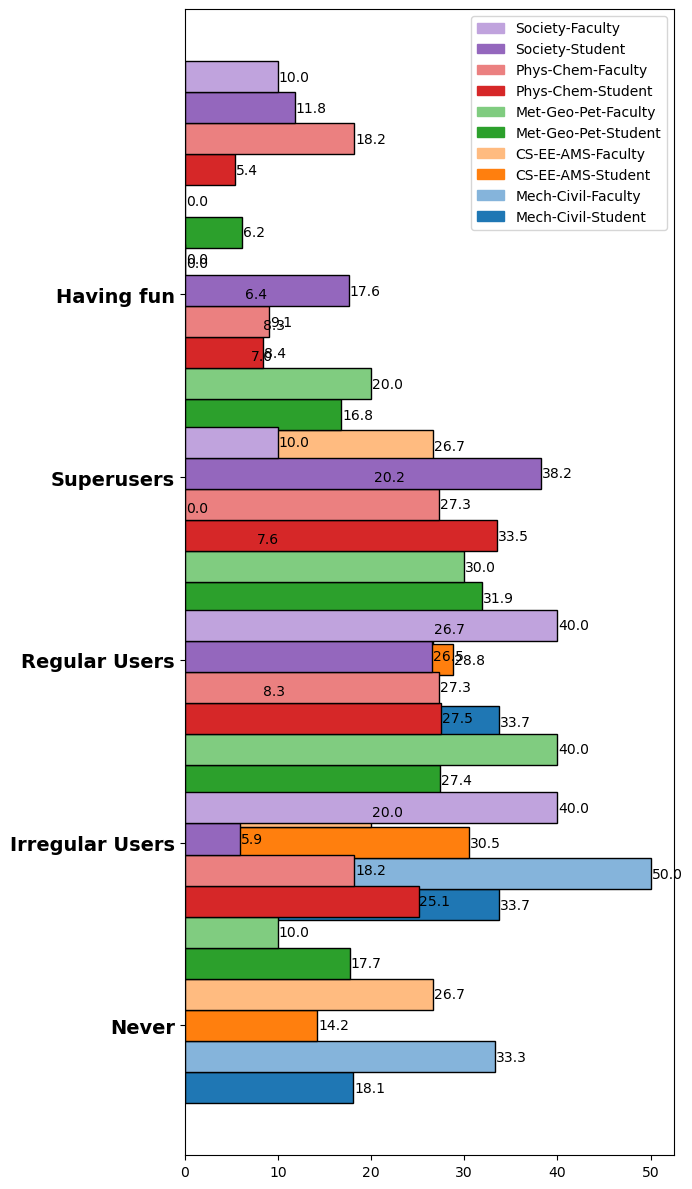

In [693]:
grouped_bar_graph_horizontal_color2(categories, mech_civil_std, mech_civil_flt, cs_ee_ams_std, cs_ee_ams_flt,
                                   met_geo_pet_std, met_geo_pet_flt, phys_chem_std, phys_chem_flt, society_std, society_flt, 
                                   'Frequency of using LLM-powered Chatbots',7,12) # size 7X7, font 16

In [745]:
values = np.array([mech_civil_std, mech_civil_flt, cs_ee_ams_std, cs_ee_ams_flt,
                                   met_geo_pet_std, met_geo_pet_flt, phys_chem_std, phys_chem_flt, society_std, society_flt, admin])

In [809]:
legend_val = ['Mech-Civil-Student', 'Mech-Civil-Faculty', 'CS-EE-AMS-Student', 'CS-EE-AMS-Faculty', 
                  'Met-Geo-Pet-Student', 'Met-Geo-Pet-Faculty', 'Phys-Chem-Student', 'Phys-Chem-Faculty', 'Society-Student', 'Society-Faculty', 'Admin-Faculty']
colors = ['#1f77b4', '#85b4db', '#ff7f0e', '#ffbb80', '#2ca02c', '#80cc80', '#d62728', '#eb8080', '#9467bd', '#c0a3dd', '#808080']
    

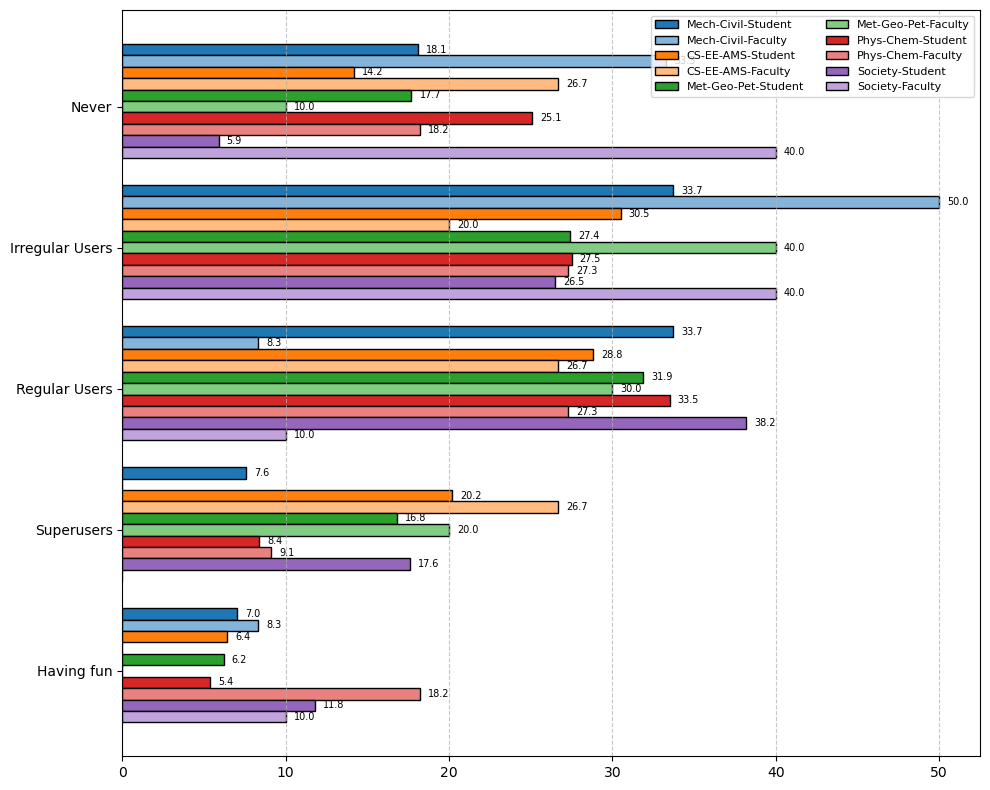

In [699]:
plot_grouped_horizontal_bar_chart3(values, categories, legend_val, colors)

In [701]:
import matplotlib.pyplot as plt
import numpy as np

def plot_grouped_vertical_bar_chart2(values, categories, legend_val, colors):
    fig, ax = plt.subplots(figsize=(12, 6))

    bar_width = 0.15
    n_bars = len(values)  # Number of groups in each category
    n_categories = len(categories)
    index = np.arange(n_categories)

    for i in range(n_bars):
        offset = (i - (n_bars - 1) / 2) * bar_width
        bars = ax.bar(index + offset, values[i], bar_width,
                      color=colors[i], edgecolor='black', label=legend_val[i])

        # Add value labels
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, height + 0.5,
                        f'{height:.1f}', ha='center', va='bottom', fontsize=7)

    ax.set_xticks(index)
    ax.set_xticklabels(categories, rotation=0)
    ax.set_ylabel('')
    ax.set_title('')
    ax.legend(loc='upper left', fontsize=8, ncol=2)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()


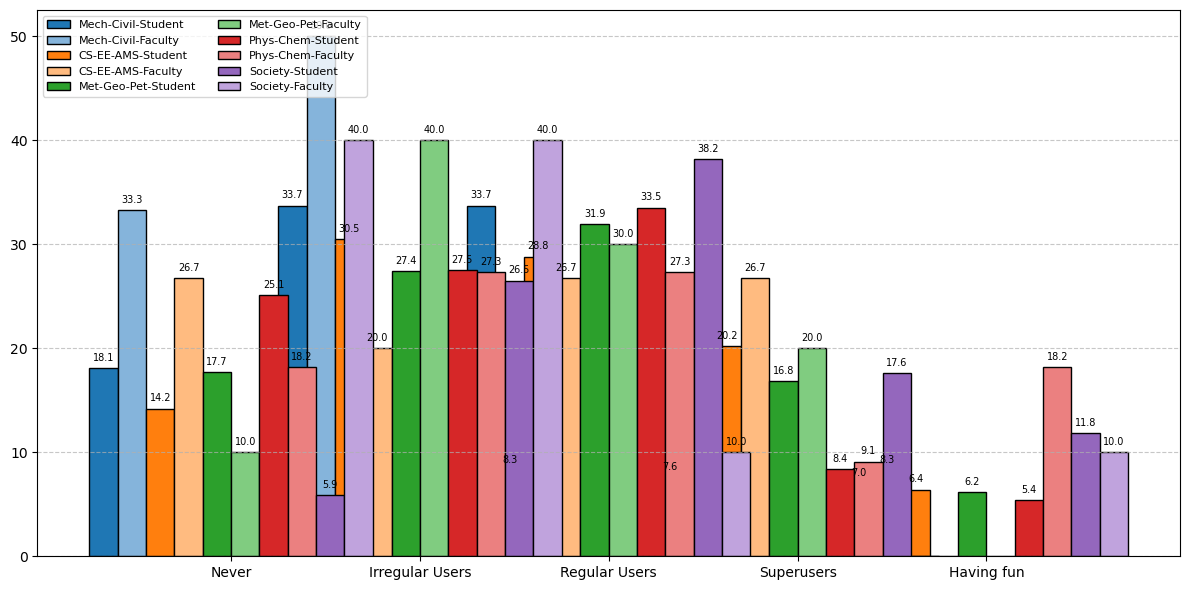

In [704]:
plot_grouped_vertical_bar_chart2(values, categories, legend_val, colors)

In [762]:
import matplotlib.pyplot as plt
import numpy as np

def plot_grouped_vertical_bar_chart_ver(values, categories, legend_val, colors):
    fig, ax = plt.subplots(figsize=(12, 6))

    n_groups = len(values)           # Number of groups (e.g., Group A, B, C)
    n_categories = len(categories)   # Number of x-axis categories
    index = np.arange(n_categories)  # Base x-tick positions

    total_width = 0.8                # Total width for all bars per group
    bar_width = total_width / n_groups

    for i in range(n_groups):
        # Shift each bar group by i * bar_width within the total width
        x_pos = index - total_width/2 + i * bar_width + bar_width/2
        bars = ax.bar(x_pos, values[i], width=bar_width, 
                      color=colors[i], edgecolor='black', label=legend_val[i])
        
        # Add value labels
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, height + 0.5,
                        f'{height:.1f}', ha='center', va='bottom', fontsize=10, rotation = 90, fontweight = 'bold', color = 'black')

    ax.set_xticks(index)
    ax.set_xticklabels(categories, rotation=0, fontweight = 'bold')
    ax.set_ylabel('')
    ax.set_title('')
    #ax.legend(loc='upper left', fontsize=8, ncol=2)
    ax.legend(loc='upper right', bbox_to_anchor=(0.99, 0.99), fontsize=12, ncol=2, borderaxespad=0)

    ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    #plt.tight_layout(rect=[0, 0, 0.8, 1])
    add = '/Users/jesanahammed/Desktop/usage_frequency'
    plt.savefig(add, dpi=300)
    plt.show()


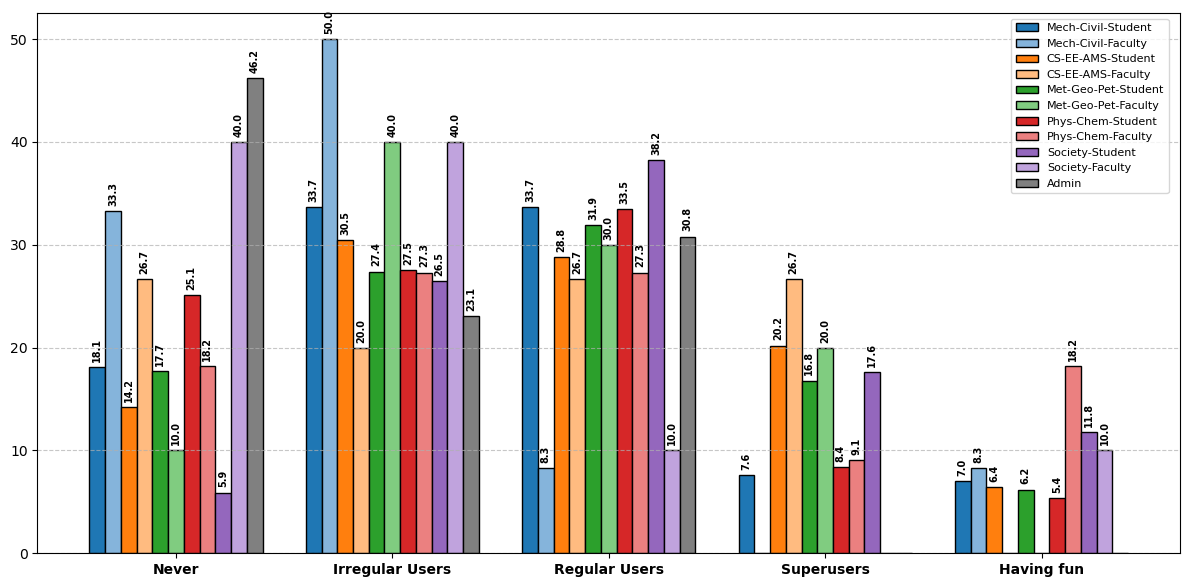

In [750]:
plot_grouped_vertical_bar_chart_ver(values, categories, legend_val, colors)

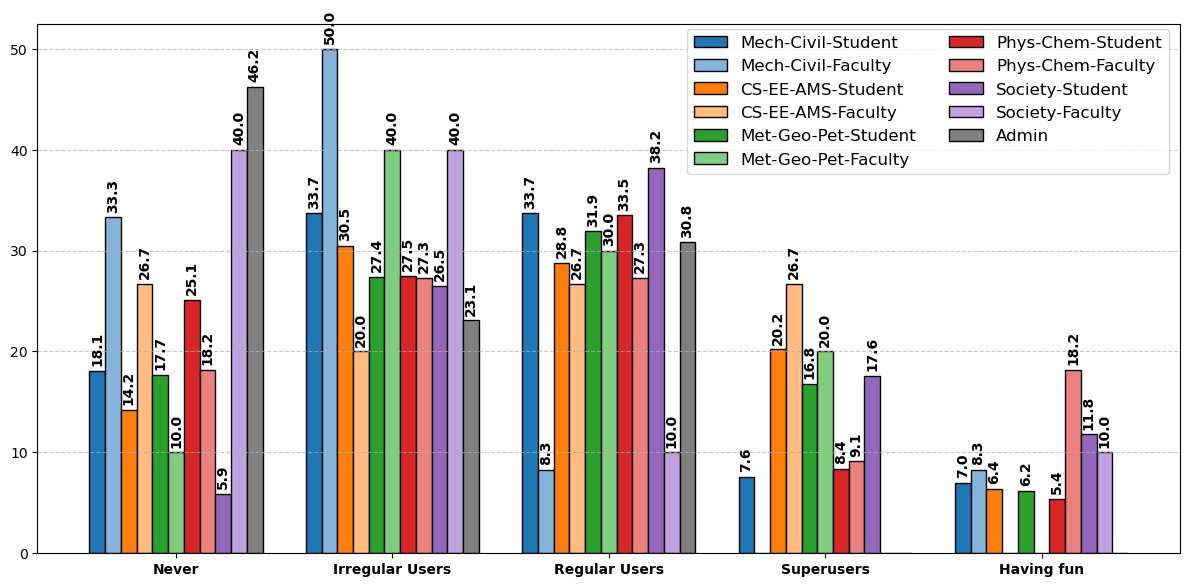

In [763]:
plot_grouped_vertical_bar_chart_ver(values, categories, legend_val, colors)

In [807]:
import matplotlib.pyplot as plt
import numpy as np

def plot_grouped_vertical_bar_chart_ver2(values, categories, legend_val, colors):
    fig, ax = plt.subplots(figsize=(12, 6))

    n_groups = len(values)           # Number of bars per category
    n_categories = len(categories)   # Number of x-axis categories
    index = np.arange(n_categories)  # Base x-tick positions

    total_width = 0.8                # Total width for all bars per category
    pair_gap = 0.03                  # <-- Space after every pair of bars

    # Adjust bar width based on number of bars & added pair gaps
    n_pairs = n_groups // 2
    bar_width = (total_width - n_pairs * pair_gap) / n_groups

    for i in range(n_groups):
        # Add extra gap after every 2nd bar
        extra_space = (i // 2) * pair_gap
        
        x_pos = index - total_width/2 + i * bar_width + bar_width/2 + extra_space
        
        # Draw bars
        bars = ax.bar(x_pos, values[i], width=bar_width,
                      color=colors[i], edgecolor='black', label=legend_val[i])
        
        # Add value labels on top of bars
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, height + 0.5,
                        f'{height:.1f}', ha='center', va='bottom',
                        fontsize=11, rotation=90, fontweight='bold', color='black')

    # Set category labels and style
    ax.set_xticks(index)
    ax.set_xticklabels(categories, rotation=0, fontsize = 15, fontweight='bold')

    # Legend formatting
    legend = ax.legend(
        loc='upper right',
        bbox_to_anchor=(0.99, 0.99),
        fontsize=12,
        ncol=2,
        borderaxespad=0
    )

    # Gridlines for y-axis
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()

    # Save and show the plot
    add = '/Users/jesanahammed/Desktop/usage_frequency.png'
    plt.savefig(add, dpi=300)
    plt.show()



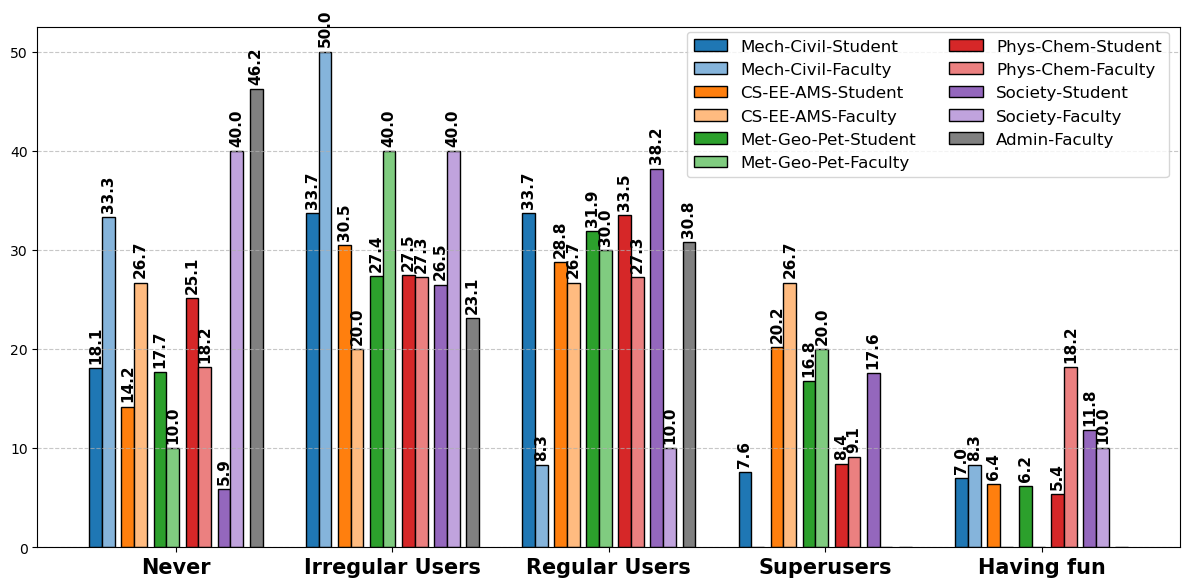

In [810]:
plot_grouped_vertical_bar_chart_ver2(values, categories, legend_val, colors)